# Poda Estruturada em Redes MLP para CIFAR-10

## Estudo Comparativo de Estratégias de Poda e Métricas de Saliência

### Objetivo

Este notebook implementa e avalia diferentes estratégias de **poda estruturada** numa arquitetura **MLP treinada no dataset CIFAR-10**, com o objetivo de reduzir a complexidade computacional do modelo preservando, tanto quanto possível, o desempenho preditivo.

São comparadas diferentes abordagens de:

- **Estratégia de poda**
  - Poda local
  - Poda global

- **Funções de saliência**
  - L1
  - L2
  - Taylor de 1.ª ordem
  - Optimal Brain Damage (OBD)

- **Rácios de sparsity**
  - 10%
  - 20%
  - 30%
  - 50%
  - 70%

Após cada processo de poda, é realizado **fine-tuning** e uma avaliação quantitativa do impacto na performance do modelo.

---
# 1. Configuração do Ambiente e Importação de Dependências

Nesta secção são importadas todas as bibliotecas necessárias para:

- Treino e avaliação do modelo (**PyTorch**)
- Transformações do dataset (**TorchVision**)
- Implementação da poda estruturada (**Torch-Pruning**)
- Métricas de avaliação e visualização

Também são carregadas funções auxiliares definidas externamente, utilizadas para cálculo de métricas, avaliação de desempenho e análise experimental.

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
import os
import pickle
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import re
import pandas as pd
from pathlib import Path

# Importações do utils.py
from utils import (
    CIFAR10MLP,
    evaluate_model,
    compute_metrics,
    train_model,
    classes
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dispositivo (foco em CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    vram_initial = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"GPU: {torch.cuda.get_device_name(device)}")
    print(f"VRAM alocada inicialmente: {vram_initial:.2f} MB")
else:
    print("AVISO: CUDA não disponível. Os resultados de VRAM serão 0.")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM alocada inicialmente: 126.03 MB


## 2. Preparação do Dataset

### Carregamento dos Dados e Split Determinístico

O dataset utilizado é o **CIFAR-10**, um conjunto de dados de classificação de imagens composto por 10 categorias.

Para garantir **reprodutibilidade experimental** e comparabilidade entre experiências de poda, é utilizado um **split determinístico**, assegurando que todas as experiências são executadas sobre os mesmos subconjuntos de treino, validação e teste.

In [32]:
# Pipeline de Transformação de Imagen
# Utilizamos a API v2 da torchvision
transform = v2.Compose([
    v2.ToImage(),  # Converte os dados brutos (PIL Image ou NumPy) para o formato de imagem interno do PyTorch.
    v2.ToDtype(torch.float32, scale=True),  # Converte para tensores de precisão simples (float32) e escala os pixéis de [0, 255] para [0.0, 1.0].
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),  # Média exata dos canais RGB calculada previamente para o CIFAR-10.
        std=(0.2470, 0.2435, 0.2616)    # Desvio padrão exato dos canais RGB do CIFAR-10. Ajuda a rede a treinar mais rápido e de forma estável.
    )
])

# Carregamento dos Datasets Brutos 
# Fazemos e aplicamos as transformações definidas acima.
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Divisão Determinística (Treino / Validação)
# Em vez de fazermos um split aleatório carregamos os índices guardados no disco.
# Isto garante reprodutibilidade: vai treinar e validar exatamente com as mesmas imagens em todas as experiências.
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

# Aplicamos os índices para criar os subconjuntos definitivos.
trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

# Criação dos DataLoaders
batch_size = 64


trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Train: 42,500 | Val: 7,500 | Test: 10,000


## 3. Carregamento do Modelo Baseline

É carregado um modelo **MLP previamente treinado no CIFAR-10**, que servirá como **baseline experimental**.

Este modelo representa o ponto de partida para todas as experiências de poda, permitindo comparar:

- Desempenho original
- Impacto da remoção de parâmetros
- Recuperação após fine-tuning

As métricas do modelo original funcionam como referência para avaliar o compromisso entre **compressão e desempenho**.

In [33]:
# Definição do Caminho do Modelo
models_dir = Path('model_dir')
PATH_MLP = models_dir / 'cifar_mlp.pt'


# Carregamos o modelo primeiro para o CPU (map_location='cpu'). Esta é uma boa prática 
# para evitar picos de memória na GPU ou erros caso o modelo tenha sido treinado num PC diferente.
# weights_only=False indica que estamos a carregar o objeto do modelo inteiro (arquitetura + pesos), 
# e não apenas o dicionário de pesos (state_dict).
baseline_model = torch.load(PATH_MLP, map_location=torch.device('cpu'), weights_only=False) 

# Transferimos o modelo para o dispositivo de processamento ativo (GPU se disponível, senão CPU).
baseline_model = baseline_model.to(device)

# Colocamos a rede em modo de avaliação. 
baseline_model.eval()

print(baseline_model)

print(f"\nTotal de parâmetros: {sum(p.numel() for p in baseline_model.parameters()):,}")

# Se estivermos a usar uma placa gráfica da NVIDIA (CUDA), verificamos a pegada de memória
# exata que a rede não podada ocupa. (1024**2 converte bytes para Megabytes).
if device.type == "cuda":
    vram_model = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"VRAM após carregar modelo: {vram_model:.2f} MB")

CIFAR10MLP(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=512, out_features=10, bias=True)
  )
)

Total de parâmetros: 8,928,778
VRAM após carregar modelo: 126.90 MB


## 4. Funções de Saliência para Estimativa de Importância dos Neurónios

A saliência de cada neurónio é calculada com base na norma dos seus pesos.
Neurónios com menor saliência são considerados menos importantes e são candidatos à remoção.

Para o neurónio $j$ na camada com pesos $W$:

**Norma L1:**  $S_j = \sum_i |w_{ij}|$

**Norma L2:**  $S_j = \sqrt{\sum_i w_{ij}^2}$

In [ ]:
import torch
import torch.nn as nn

# Saliência por Magnitude Estática (Norma L1 / Distância de Manhattan)
def compute_l1_saliency(layer: nn.Linear, **kwargs) -> torch.Tensor:
    """
    Calcula a importância topológica de cada neurónio baseando-se na Norma L1.
    
    A premissa da Norma L1 assume que o valor linear de um peso dita a sua 
    importância. Ao contrário da Norma L2 (que penaliza e destaca os valores 
    extremos através da elevação ao quadrado), a L1 avalia a contribuição crua 
    e proporcional de cada ligação.
    """
    
    # Extração direta do tensor numérico subjacente, contornando a árvore 
    # de derivadas do PyTorch (Autograd) para garantir operações de O(1) 
    # em memória VRAM e processamento escalar puro.
    W = layer.weight.data 
    
    # A operação torch.abs() é matematicamente vital. Numa rede neuronal, um peso
    # fortemente excitatório (+1.5) e um fortemente inibitório (-1.5) têm ambos 
    # um enorme impacto na rede. Sem o valor absoluto, ao somá-los, eles 
    # anular-se-iam mutuamente (0.0), classificando o neurónio erradamente como "inútil".
    
    # O torch.sum(..., dim=1) agrupa a "força" absoluta de todas as conexões 
    # que entram num único neurónio de saída. Isto traduz o cálculo de uma Poda 
    # Não-Estruturada (peso a peso) num verdadeiro mecanismo de Poda Estruturada 
    # (nó a nó). Devolve um tensor 1D com a pontuação final de cada neurónio.
    return torch.sum(torch.abs(W), dim=1)

In [ ]:
import torch
import torch.nn as nn

# Saliência por Magnitude Estática (Norma L2 / Distância Euclidiana)
def compute_l2_saliency(layer: nn.Linear, **kwargs) -> torch.Tensor:
    """
    Calcula a importância topológica de cada neurónio baseando-se na Norma L2 (Euclidiana).
    
    Ao contrário dos métodos orientados a dados (Taylor/OBD), esta é uma métrica puramente 
    estática e "cega" ao fluxo de erro. A premissa heurística é que pesos com maior 
    magnitude global (distância geométrica à origem) retêm mais informação representacional,
    enquanto matrizes com valores próximos de zero são redundantes.
    """
    
    # Acedemos diretamente aos valores numéricos brutos da matriz de pesos da camada 
    # através do atributo .data. Isto ignora o grafo de computação do PyTorch (Autograd),
    # garantindo que a extração não consome memória VRAM extra nem interfere com os gradientes.
    W = layer.weight.data
    
    # A função torch.norm(..., p=2) calcula a raiz quadrada da soma dos quadrados dos pesos.
    # O argumento crítico aqui é o 'dim=1', que define a Poda Estruturada:
    # Em vez de avaliar cada ligação individual (Poda Não-Estruturada), agregamos a "energia" 
    # de todas as ligações de entrada que alimentam um único neurónio de saída.
    # O retorno é um vetor 1D contendo a magnitude consolidada de cada neurónio da camada.
    return torch.norm(W, p=2, dim=1)


In [ ]:
# Saliência por Informação de Gradiente (Expansão de Taylor de 1ª Ordem)
def compute_taylor_saliency(layer: nn.Module, model: nn.Module = None, calibration_loader: DataLoader = None, device: torch.device = None, **kwargs) -> torch.Tensor:
    """
    Calcula a importância dos neurónios usando uma aproximação de Taylor de 1ª Ordem.
    Avalia a sensibilidade da função de Perda (Loss) face à remoção de um neurónio.
    A saliência é estimada pelo produto absoluto entre a ativação do nó e o seu gradiente.
    """
    activations = []
    gradients = []

    # Captura a saída da camada durante o fluxo de ida (Forward Pass)
    def f_hook(module, input, output): 
        activations.append(output.detach())
        
    # Captura a derivada do erro da camada durante o fluxo de retorno (Backward Pass)
    def b_hook(module, grad_in, grad_out): 
        gradients.append(grad_out[0].detach())
    
    # Injetamos fisicamente as sondas na camada que queremos avaliar
    h_f = layer.register_forward_hook(f_hook)
    h_b = layer.register_full_backward_hook(b_hook)
    
    # Colocamos o modelo em modo de avaliação para estabilizar camadas estocásticas (ex: Dropout)
    model.eval()
    
    # Extraímos um único batch de dados para simular o comportamento real da rede
    images, labels = next(iter(calibration_loader))
    images, labels = images.to(device), labels.to(device)
    
    # Tratamento topológico: Achatar tensores 4D (ex: CIFAR-10) num vetor 1D
    # Crucial para evitar incompatibilidade de matrizes quando operamos numa rede densa (MLP)
    if len(images.shape) > 2:
        images = images.view(images.size(0), -1)
        
    images.requires_grad_(True)

    # Passamos os dados pela rede. O 'f_hook' dispara automaticamente e guarda as ativações.
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    
    # Calculamos os gradientes. O 'b_hook' dispara automaticamente e guarda o fluxo do erro.
    model.zero_grad()
    loss.backward()

    # Removemos as sondas para evitar memory leaks nas iterações seguintes
    h_f.remove()
    h_b.remove()
    
    act = activations[0]
    grad = gradients[0]
    
    # Saliência = | Ativação × Gradiente |
    # A média (mean) colapsa a dimensão do Batch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Saliência por Optimal Brain Damage (Aproximação da Hessiana / 2ª Ordem)
def compute_obd_saliency(layer: nn.Linear, model: nn.Module = None, calibration_loader: DataLoader = None, device: torch.device = None, **kwargs) -> torch.Tensor:
    """
    Calcula a importância topológica através da aproximação da Matriz Hessiana (2ª Derivada).
    Baseado no método clássico de Yann LeCun, avalia a curvatura da função de perda (Loss).
    Como a computação exata da Hessiana é proibitiva, utiliza a Informação de Fisher Empírica
    (o quadrado do gradiente) como aproximação da curvatura.
    """
    W = layer.weight.data
    
    # Ao criar a cópia de trabalho da rede (deepcopy), os tensores .grad são habitualmente 
    # descartados pelo PyTorch para poupar memória VRAM.
    # Este bloco atua como salvaguarda: se a camada não tiver gradiente, força uma passagem 
    # completa (Forward + Backward) de um lote de calibração para repovoar os tensores de gradiente
    # em todas as camadas da rede simultaneamente.
    if layer.weight.grad is None and model is not None and calibration_loader is not None:
        model.eval()
        model.zero_grad()
        
        # Extração de um lote amostral para cálculo da derivada
        images, labels = next(iter(calibration_loader))
        images, labels = images.to(device), labels.to(device)
        
        # Ajuste dimensional para arquitetura estritamente densa (MLP)
        if len(images.shape) > 2:
            images = images.view(images.size(0), -1)
            
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        
        # O disparo do backward() preenche automaticamente os atributos .grad 
        # de todos os pesos do modelo (model.parameters)
        loss.backward() 
        
    if layer.weight.grad is not None:
        grad_W = layer.weight.grad.data
        
        # FÓRMULA OBD APROXIMADA: 0.5 * (Derivada^2) * (Peso^2)
        # Ao invés de usar a Hessiana real, elevamos os gradientes de 1ª ordem ao quadrado.
        # Isto penaliza severamente a remoção de pesos que se encontram em "vales" íngremes 
        # da paisagem de erro (alta curvatura).
        importance_matrix = 0.5 * (grad_W ** 2) * (W ** 2)
        
        # ADAPTAÇÃO PARA PODA ESTRUTURADA
        # O OBD original avaliava pesos individuais. Para podar neurónios inteiros,
        # somamos a importância de todas as conexões de entrada (dim=1) desse neurónio.
        # O resultado é um vetor 1D com a saliência agregada por nó.
        saliency = torch.sum(importance_matrix, dim=1)
    else:
        # Fallback de segurança algébrica caso a extração falhe por motivos arquiteturais
        saliency = torch.zeros(layer.out_features, device=W.device)
        
    return saliency


Funções de saliência prontas e unificadas: L1, L2, Taylor, OBD


### Reconstrução Física das Camadas (In-Place Tensor Manipulation)

Em vez de mascarar pesos a zero, a arquitetura da rede é **fisicamente reconstruída**.
Isto garante que as matrizes de pesos continuam a multiplicar corretamente após a poda,
ajustando dinamicamente `in_features` e `out_features` das camadas subsequentes.

Isto reduz:
- Contagem de parâmetros
- Consumo de memória
- Latência de inferência

In [38]:
def apply_layer_pruning_physical(
    classifier: nn.Sequential,
    layer_idx: int,
    indices_to_keep: torch.Tensor
):
    """
    Remove fisicamente neurónios de uma camada Linear alvo e propaga as
    alterações dimensionais para as camadas adjacentes a jusante (downstream).
    
    A arquitetura é fisicamente reconstruída.
    Reduz a contagem de parâmetros reais, liberta memória VRAM e acelera a latência de inferência.
    """
    
    # Preparação da Camada Alvo
    layer = classifier[layer_idx]
    
    # Ordenar os índices garante que a topologia lógica da rede se mantém (os neurónios 
    # não trocam de lugar entre si, apenas os "espaços vazios" são removidos).
    indices_to_keep = torch.sort(indices_to_keep).values
    num_to_keep = len(indices_to_keep)
    
    # Numa camada nn.Linear, a matriz de pesos tem a forma: [out_features, in_features].
    # Ao cortarmos as linhas correspondentes aos índices a remover, estamos literalmente 
    # a apagar os neurónios de saída dessa camada.
    layer.weight = nn.Parameter(layer.weight.data[indices_to_keep, :])
    
    # O bias é um vetor 1D [out_features]. Cortamos as mesmas posições.
    if layer.bias is not None:
        layer.bias = nn.Parameter(layer.bias.data[indices_to_keep])
        
    # Atualizamos a propriedade da classe para que o PyTorch saiba o novo tamanho
    layer.out_features = num_to_keep
    
    
    # Se cortámos a saída da camada A, a entrada da camada B vai receber menos valores.
    # Temos de varrer as camadas seguintes no nn.Sequential para ajustar quem recebe estes dados.
    next_linear_idx = None
    for i in range(layer_idx + 1, len(classifier)):
        
        # Se encontrarmos uma camada de Normalização (BatchNorm1d)
        if isinstance(classifier[i], nn.BatchNorm1d):
            bn = classifier[i]
            # O BatchNorm tem 1 parâmetro de escala e deslocamento por neurónio (canal).
            # Temos de cortar exatamente os mesmos índices que cortámos na camada Linear anterior.
            bn.weight = nn.Parameter(bn.weight.data[indices_to_keep])
            bn.bias = nn.Parameter(bn.bias.data[indices_to_keep])
            
            # O BatchNorm guarda estatísticas em tempo real (médias e variâncias).
            # Se não cortarmos isto, a rede entra em colapso matemático durante a validação.
            bn.running_mean = bn.running_mean[indices_to_keep]
            bn.running_var = bn.running_var[indices_to_keep]
            bn.num_features = num_to_keep
            
        # Se encontrarmos a próxima camada Linear, guardamos o índice e paramos a procura
        elif isinstance(classifier[i], nn.Linear):
            next_linear_idx = i
            break
            
    # Para a multiplicação de matrizes funcionar: (A x B) * (B x C). Se o 'B' da primeira
    # matriz encolheu, o 'B' da segunda matriz também tem de encolher
    if next_linear_idx is not None:
        next_layer = classifier[next_linear_idx]
        
        # A matriz da próxima camada tem a forma [out_features_next, in_features_current].
        # Aqui, mantemos todas as linhas (:), mas cortamos as colunas (índices) 
        # que correspondiam aos neurónios que apagámos anteriormente
        next_layer.weight = nn.Parameter(
            next_layer.weight.data[:, indices_to_keep]
        )
        
        # Atualizamos a propriedade de entrada para que o Forward Pass não dê erro de dimensões
        next_layer.in_features = num_to_keep

print("Função apply_layer_pruning_physical definida e documentada.")

Função apply_layer_pruning_physical definida e documentada.


### Poda Estruturada Local (Local Structured Pruning)

Na poda **local**, cada camada oculta perde exatamente a mesma fração de neurónios
(`prune_ratio`). O ranking é feito **independentemente** por camada.

In [ ]:
def prune_mlp_local(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA LOCAL:  Aplica um rácio de poda fixo e cego a cada camada.
    
    Ao contrário da Poda Global (que avalia a rede como um todo), a Poda Local
    obriga a que cada camada oculta perca exatamente a mesma percentagem de 
    neurónios (definida por 'prune_ratio'), independentemente de essa camada 
    ser muito ou pouco importante para a extração de características.
    """

    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    # Fazemos uma cópia profunda (deepcopy) do modelo.
    # Isto garante que o modelo 'baseline' original que está na memória não é destruído,
    # permitindo-nos correr várias experiências a partir do mesmo ponto de partida.
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Procuramos todas as camadas do tipo nn.Linear no modelo.
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    # O [:-1] exclui a última camada (a de saída com 10 classes). 
    # Nunca podar a camada de saída, caso contrário a rede perde a capacidade de classificar as 10 categorias
    hidden_linear_indices = linear_indices[:-1]
    
    print(f"  Poda Local (ratio={prune_ratio:.2f}) nas camadas: "
          f"{hidden_linear_indices}")
    

    # Recolhemos a importância de todos os neurónios antes de fazer qualquer corte.
    # Se cortássemos a Camada 1 antes de avaliar a Camada 2, as ativações e gradientes 
    # (usados no Taylor) chegariam distorcidos à Camada 2, arruinando a avaliação.
    saliencies_dict = {}
    for idx in hidden_linear_indices:
        layer_target = classifier[idx]
        
        saliencies_dict[idx] = saliency_fn(
            layer=layer_target,
            model=pruned_model,
            calibration_loader=trainloader,
            device=device
        )


    for idx in hidden_linear_indices:
        # Recuperar os scores que guardámos anteriormente
        saliency = saliencies_dict[idx]
        
        # Cálculo da "Quota" Local:
        # Descobrimos quantos neurónios a camada tem e calculamos o número exato a manter.
        # O max(1, ...) é um mecanismo de segurança para garantir que uma camada nunca fica vazia (colapso da rede).
        n_neurons = saliency.shape[0]
        n_keep = max(1, int(n_neurons * (1 - prune_ratio)))
        
        # Ordenamos os neurónios do mais alto (descending=True) para o mais baixo.
        # O [:n_keep] seleciona apenas o top-K definido pela nossa quota.
        indices_to_keep = torch.argsort(saliency, descending=True)[:n_keep]
        
        print(f"    Camada[{idx}]: {n_neurons} → {n_keep} neurónios "
              f"(removidos {n_neurons - n_keep})")
        
        # Chamamos a função que destrói fisicamente as linhas e colunas desnecessárias
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)

print("Função prune_mlp_local definida e documentada.")

Função prune_mlp_local definida e documentada.


---
## 2. Lógica de Poda Global (Global Structured Pruning)

Na poda **global**, a saliência é calculada para **TODOS** os neurónios de **TODAS**
as camadas ocultas, criando um **ranking unificado**. O bottom `prune_ratio` é removido
globalmente — independentemente da camada a que pertençam.

**Vantagem sobre a poda local:**
Preserva mais capacidade nas camadas que são realmente importantes, enquanto
comprime agressivamente camadas com neurónios redundantes.

$$\text{Threshold} = \text{kth\_smallest}\left(\bigcup_{l \in \text{hidden}} \{S_j^{(l)}\}_{j=1}^{n_l},\; k = \lfloor N_{\text{total}} \times r \rfloor\right)$$

In [ ]:
import copy
import torch
import torch.nn as nn

def prune_mlp_global(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA GLOBAL: Avalia a rede como um ecossistema único.
    
    Em vez de forçar cada camada a perder uma percentagem fixa (Poda Local), 
    este método junta as pontuações de importância de TODOS os neurónios ocultos 
    num único "saco" gigante. Depois, corta os X% piores a nível global.
    Isto permite que camadas com muita redundância sejam podadas agressivamente, 
    enquanto camadas críticas são automaticamente protegidas pela matemática.
    """
    
    # Mesmo que no Local
    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    # Criamos a nossa cópia de trabalho. 
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Extrair diretamente do modelo de trabalho atual para não haver falhas de Hooks
    camadas_lineares = [module for module in classifier if isinstance(module, nn.Linear)]
    
    # Identificar índices originais das camadas Linear no classifier
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    # Ocultas apenas (exclui a última camada de classificação para não quebrar o output 10D)
    hidden_linear_indices = linear_indices[:-1]
    
    all_saliencies = []
    layer_boundaries = []  # Serve para sabermos a que camada pertence cada pontuação mais tarde
    offset = 0
    
    for idx in hidden_linear_indices:
        layer_target = classifier[idx]
        
        # model=pruned_model garante que as sondas se ligam à rede que efetivamente vai treinar
        scores = saliency_fn(
            layer=layer_target,
            model=pruned_model,  
            calibration_loader=trainloader, 
            device=device                   
        )
            
        all_saliencies.append(scores)
        n = scores.numel() # Conta quantos neurónios tem esta camada
        
        # Guardamos as "fronteiras": ex: a camada 1 vai do neurónio 0 ao 2048
        layer_boundaries.append((offset, offset + n, idx))
        offset += n
    
    # Juntamos todas as pontuações num único tensor 1D gigante
    global_pool = torch.cat(all_saliencies)
    total_neurons = global_pool.numel()
    
    # Descobrimos exatamente quantos neurónios temos de deitar fora no total
    num_to_prune = int(total_neurons * prune_ratio)
    
    # o torch.kthvalue ordena o pool gigante e encontra 
    # o valor exato que separa os "fracos" dos "fortes" com base na nossa quota.
    if num_to_prune > 0 and num_to_prune < total_neurons:
        global_threshold = torch.kthvalue(
            global_pool, num_to_prune
        ).values.item()
    else:
        global_threshold = -float('inf')
    
    print(f"  Poda Global → Total neurónios: {total_neurons} | "
          f"Alvo remoção: {num_to_prune} | "
          f"Limiar: {global_threshold:.6f}")
    
    for i, (start, end, idx) in enumerate(layer_boundaries):
        layer_target = classifier[idx]
        
        # Usamos as saliências exatas que geraram o limiar. 
        # Se voltássemos a chamar o DataLoader para o Taylor agora, a aleatoriedade 
        # das imagens iria gerar valores diferentes e o limiar cortaria a quantidade errada
        saliency = all_saliencies[i]
        
        # Mantemos apenas os neurónios cuja importância é superior a nota de corte global
        indices_to_keep = torch.where(saliency > global_threshold)[0]
        
        # Se uma camada inteira for classificada como "lixo" pelo limiar global e a 
        # lista de índices ficar vazia, a rede colapsaria matematicamente no Forward Pass.
        # Para evitar isso, forçamos a camada a manter pelo menos o seu neurónio mais forte.
        if len(indices_to_keep) == 0:
            indices_to_keep = torch.argmax(saliency).unsqueeze(0)
        
        original_size = layer_target.out_features
        print(f"    Camada[{idx}]: {original_size} → "
              f"{len(indices_to_keep)} neurónios "
              f"(removidos {original_size - len(indices_to_keep)}, "
              f"{(1 - len(indices_to_keep)/original_size)*100:.1f}%)")
        
        # Aplicamos o corte físico à camada
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)

print(" Função prune_mlp_global corrigida, comentada e pronta para o relatório.")

 Função prune_mlp_global corrigida, comentada e pronta para o relatório.


---
## 3. Ciclo de Fine-Tuning (Iterative Post-Training)

Após o corte in-place dos tensores, os pesos sobreviventes precisam de ser
recalibrados. Este fine-tuning rápido utiliza **SGD com Momentum** (estável
para recalibração pós-poda) durante poucas epochs para recuperar a exatidão.

In [ ]:
def fine_tune(
    model: nn.Module,
    trainloader: DataLoader,
    valloader: DataLoader,
    epochs: int = 5,
    lr: float = 1e-4, 
    optimizer_type: str = "sgd",
    device: torch.device = device
) -> nn.Module:
    """
    Após remover neurónios, a rede sofre um esquecimento parcial. 
    O fine-tuning serve para re-treinar os pesos sobreviventes para que eles 
    assumam o trabalho dos neurónios que foram apagados.
    
    O Learning Rate (lr) é fixado num valor muito 
    baixo (1e-4) de propósito. Se usássemos o LR alto do treino inicial (ex: 1e-2), 
    destruiríamos o conhecimento que os pesos sobreviventes ainda têm.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Escolha do Otimizador
    # Em Poda de Redes, o SGD com Momentum costuma ser preferido ao Adam na fase de 
    # fine-tuning porque o Adam pode ser demasiado agressivo a recalcular os momentos 
    # dos gradientes após a arquitetura ter sido "desfeita".
    if optimizer_type.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9
        )
    
    print(f"  Fine-tuning: {epochs} epochs | LR={lr} | "
          f"Optimizer={optimizer_type.upper()}")
    
    # Ciclo de Treino
    for epoch in range(epochs):
        model.train() # Coloca a rede em modo de treino (ativa Dropout, atualiza BatchNorm)
        running_loss = 0.0
        
        # Barra de progresso visual (tqdm) para não ficarmos a olhar para o ecrã em branco
        progress_bar = tqdm(
            trainloader, 
            desc=f"    Epoch [{epoch+1}/{epochs}]", 
            leave=False
        )
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Limpar gradientes do lote anterior
            optimizer.zero_grad()
            
            # Forward pass: passar as imagens pela rede
            outputs = model(images)
            
            # Calcular o erro (Loss)
            loss = criterion(outputs, labels)
            
            # Backward pass: calcular as derivadas (gradientes) para os pesos sobreviventes
            loss.backward()
            
            # Dar um pequeno passo na direção do mínimo do erro (ajustar pesos)
            optimizer.step()
            
            # Acumular o erro para a média da época
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        train_loss = running_loss / len(trainloader)
        
        
        # Ciclo de Validação 
        model.eval() # Congela o comportamento de treino (desativa Dropout)
        val_loss = 0.0
        correct = 0
        total = 0
        
        # torch.no_grad(): desliga o motor de gradientes do PyTorch.
        with torch.no_grad():
            for images, labels in valloader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Extrair a classe com maior probabilidade
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss /= len(valloader)
        val_acc = 100.0 * correct / total
        
        # Resumo da época
        print(f"    Epoch [{epoch+1}/{epochs}] Terminado -> "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")
    
    return model

print("Função fine_tune definida com sucesso.")

Função fine_tune definida com sucesso.


# Pipeline de Avaliação Automatizada

### Função de Avaliação Abrangente

Para cada modelo (baseline ou podado), regista:
- **a)** Exatidão (Accuracy) de teste
- **b)** Contagem de parâmetros ativos
- **c)** Tempo real de inferência (Latência em segundos)
- **d)** Uso de VRAM no dispositivo (se aplicável)

In [42]:
def evaluate_comprehensive(
    model: nn.Module,
    testloader: DataLoader,
    device: torch.device,
    num_inference_runs: int = 3
) -> dict:
    """
    AVALIAÇÃO MULTIDIMENSIONAL DO MODELO
    
    Esta função não olha apenas para a taxa de acerto (Accuracy). Para provar 
    que a Poda Estruturada funciona, temos de medir ganhos físicos reais: 
    espaço em disco (parâmetros), velocidade (latência) e memória de vídeo (VRAM).
    """
    model = model.to(device)
    

    # Coloca a rede em modo de inferência (desliga Dropout e estabiliza BatchNorm)
    model.eval()
    
    # Soma total de pesos e bias sobreviventes. Como usamos poda estruturada (remoção 
    # de colunas/linhas), este número vai ser fisicamente menor que o baseline.
    total_params = sum(p.numel() for p in model.parameters())
    
    
    # Limpamos o histórico de memória máxima do PyTorch antes de testar.
    # Se não fizéssemos isto, a função iria devolver a memória gasta durante o 
    # fine-tuning (que é sempre muito maior por causa dos gradientes) e não a 
    # memória real necessária apenas para inferência.
    vram_mb = 0.0
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    
    
    # Extraímos as previsões usando a função no utils.py
    y_true, y_pred, _ = evaluate_model(model, testloader, device)
    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]
    
    
    # Corremos a inferência várias vezes e fazemos a média para diluir 
    # flutuações do sistema operativo ou picos de CPU.
    latencies = []
    for _ in range(num_inference_runs):
        
        # A GPU trabalha de forma paralela ao CPU. Se não usarmos o synchronize(),
        # o relógio do CPU arranca e pára imediatamente enquanto a GPU ainda está 
        # a processar os dados em pano de fundo, dando uma latência falsamente rápida.
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        start_time = time.perf_counter() # Inicia o cronómetro 
        
        with torch.no_grad(): # Desliga o motor de gradientes (mais rápido e poupa VRAM)
            for images, labels in testloader:
                images = images.to(device)
                _ = model(images) # Só queremos medir a passagem, ignoramos o output
        
        # Esperamos que a GPU termine todo o trabalho antes de parar o relógio
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        end_time = time.perf_counter()
        latencies.append(end_time - start_time)
    
    avg_latency = np.mean(latencies)
    
    
    # Registamos o pico máximo absoluto de memória gráfica alocada durante este teste
    if device.type == "cuda":
        vram_mb = torch.cuda.max_memory_allocated(device) / (1024**2) # Converte bytes para Megabytes
    
    
    return {
        "accuracy": accuracy,
        "param_count": total_params,
        "latency_seconds": avg_latency,
        "vram_mb": vram_mb
    }

In [ ]:
def run_pruning_pipeline(
    model: nn.Module,
    prune_fn,           # Ex: prune_mlp_local ou prune_mlp_global
    saliency_fn,        # Ex: compute_l1_saliency, compute_taylor_saliency
    target_ratio: float, # O rácio final pretendido face ao modelo original (ex: 0.30 para 30%)
    strategy: str = "one-shot", 
    epochs_per_step: int = 5,
    lr: float = 1e-4,
    trainloader = trainloader,
    valloader = valloader,
    device = device
) -> nn.Module:
    """
    Esta função gere o fluxo de alto nível da poda, decidindo se a rede 
    é podada de uma só vez (One-Shot) ou em múltiplas fases cirúrgicas (Iterativa).
    """
    # cria uma cópia isolada para não destruir o modelo que está na memória principal
    current_model = copy.deepcopy(model)
    
    # Abordagem de força bruta: remove logo X% dos pesos e tenta recuperar de seguida.
    # É rápido, mas em compressões elevadas (ex: 50%) sofre de Esquecimento 
    # irrecuperável, servindo como a nossa baseline de comparação ("o que não fazer")
    if strategy.lower() == "one-shot":
        print(f"\n A iniciar Poda ONE-SHOT (Alvo: {target_ratio*100:.0f}%)")
        current_model = prune_fn(current_model, target_ratio, saliency_fn)
        current_model = fine_tune(
            current_model, trainloader, valloader, 
            epochs=epochs_per_step, lr=lr, device=device
        )
        
    # Semelhante a uma cirurgia onde cortamos um pouco, deixamos a rede estabilizar 
    # (fine-tuning intermédio), voltamos a cortar, e assim sucessivamente.
    elif strategy.lower() == "iterative":
        print(f"\n A iniciar Poda ITERATIVA (Alvo Final: {target_ratio*100:.0f}%)")
        num_steps = 3 # O processo é dividido em 3 rondas
        
        # Quantidade absoluta a remover do modelo original em cada passo.
        # Ex: Se o alvo final é 30%, queremos remover 10% da rede original por passo.
        absolute_step_chunk = target_ratio / num_steps
        
        pre_ft = None
        
        for step in range(num_steps):
            # Se já cortámos 10% no Passo 1, a rede atual só tem 90% do tamanho.
            # Se no Passo 2 pedirmos à função de poda para cortar "10%", ela vai cortar 10% de 90 (que é 9%), falhando o alvo matemático.
            # Para corrigir isto, temos de calcular o rácio relativo ao tamanho atual da rede.
            
            # Quanto da rede original ainda nos resta neste exato momento?
            pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
            
            # Qual é a percentagem da rede atual que corresponde ao chunk absoluto que queremos remover?
            # Ex (Passo 2): 0.10 / 0.90 = 0.1111 (Temos de pedir à função de poda para cortar 11.11% do que resta para perfazer 10% do total)
            current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
            
            print(f"\n--- Roda Iterativa {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total | Rácio relativo no passo: {current_step_ratio*100:.1f}%) ---")
            
            # Executar o corte físico com o rácio matematicamente corrigido
            current_model = prune_fn(current_model, current_step_ratio, saliency_fn)
            
            # Capturar as métricas logo após o primeiro impacto (antes de qualquer recuperação) para o gráfico final
            if step == 0 and 'pre_ft' in locals():
                pre_ft = evaluate_comprehensive(current_model, testloader, device)
                print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']*100:.2f}%")
            
            # Não precisamos de um treino completo (ex: 5 épocas) nos passos intermédios, 
            # pois a rede vai voltar a ser mutilada logo a seguir.
            # Metade das épocas (max(1, 5//2) = 2) chega para estabilizar os gradientes.
            # O fine-tuning completo só ocorre no último passo, quando a arquitetura está fechada.
            is_last_step = (step == num_steps - 1)
            step_epochs = epochs_per_step if is_last_step else max(1, epochs_per_step // 2)
            
            current_model = fine_tune(
                current_model, trainloader, valloader, 
                epochs=step_epochs, lr=lr, device=device
            )
            
    return current_model

print("Controlador run_pruning_pipeline documentado e pronto.")

Controlador run_pruning_pipeline documentado e pronto.


---
# 5. Pipeline Experimental de Poda

### Processo Experimental

O estudo segue um pipeline sistemático de experimentação para avaliar o impacto da poda em diferentes cenários.

Para cada combinação de:

- **Estratégia de poda**
  - Local
  - Global

- **Função de saliência**
  - L1
  - L2
  - Taylor
  - OBD

- **Rácio de sparsity**
  - 10%
  - 20%
  - 30%
  - 40%
  - 50%
  - 70%

é executado o seguinte fluxo:

1. **Carregamento do modelo baseline**
2. **Aplicação da poda estruturada**
3. **Fine-tuning do modelo podado**
4. **Avaliação quantitativa**
5. **Armazenamento de métricas e checkpoints**

Este procedimento permite medir o impacto da poda na generalização, eficiência computacional e capacidade de recuperação do modelo.

In [44]:
import os

save_dir = Path('modelos_podados_mlp')
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
import copy
import torch
import torch.nn as nn
from pathlib import Path

# Configuração de Diretórios e Hiperparâmetros

save_dir = Path('modelos_podados_mlp')
save_dir.mkdir(parents=True, exist_ok=True)

sparsity_ratios = [0.10, 0.20, 0.30, 0.40, 0.50]
fine_tune_epochs = 5
fine_tune_lr = 1e-4  
criterion = nn.CrossEntropyLoss()
estrategias = ["one-shot", "iterative"]
skip_if_exists = True  # Flag de segurança

# Mapeamento de Métodos para as TUAS funções manuais
pruning_methods = {
    "Local L1 (Magnitude)":       (prune_mlp_local, compute_l1_saliency),
    "Local L2 (Magnitude)":       (prune_mlp_local, compute_l2_saliency),
    "Local Taylor (Gradiente)":   (prune_mlp_local, compute_taylor_saliency),
    "Local OBD (Hessiana)":       (prune_mlp_local, compute_obd_saliency),
    
    "Global L1 (Magnitude)":      (prune_mlp_global, compute_l1_saliency),
    "Global L2 (Magnitude)":      (prune_mlp_global, compute_l2_saliency),
    "Global Taylor (Gradiente)":  (prune_mlp_global, compute_taylor_saliency),
    "Global OBD (Hessiana)":      (prune_mlp_global, compute_obd_saliency)
}

# Avaliação do Baseline

print("=" * 70)
print("AVALIAÇÃO DO MODELO MLP BASELINE")
print("=" * 70)

_, _, baseline_results = evaluate_model(baseline_model, testloader, criterion, device=device)
baseline_results['param_count'] = sum(p.numel() for p in baseline_model.parameters())

print(f"  Accuracy:   {baseline_results['accuracy']:.4f}")
print(f"  Parâmetros: {baseline_results['param_count']:,}") 
print(f"  Latência:   {baseline_results.get('latency', 0) / 1000:.4f} s")

# Loop Principal de Experiências (MODO MANUAL)

all_results = {}
total_experiencias = len(pruning_methods) * len(estrategias) * len(sparsity_ratios)
contador = 1

for method_name, (prune_fn, saliency_fn) in pruning_methods.items():
    for estrategia in estrategias:
        full_method_key = f"{method_name} ({estrategia})"
        
        print(f"\n{'=' * 70}")
        print(f"MÉTODO: {full_method_key}")
        print(f"{'=' * 70}")
        
        method_results = []
        
        for ratio in sparsity_ratios:
            # VERIFICAÇÃO DE EXISTÊNCIA (Antecipada)
            partes_nome = method_name.split(" ")
            escopo = partes_nome[0]
            norma = partes_nome[1]
            
            pasta_especifica = save_dir / escopo / norma
            pasta_especifica.mkdir(parents=True, exist_ok=True)
            
            model_filename = f"MLP_{estrategia}_{int(ratio*100)}pct.pt"
            model_path = pasta_especifica / model_filename
            
            print(f"\n{'─' * 55}")
            print(f"  [{contador}/{total_experiencias}] Sparsity Ratio Alvo: {ratio*100:.0f}%")
            print(f"{'─' * 55}")
            contador += 1
            
            if skip_if_exists and model_path.exists():
                print(f"  [Ignorado] O ficheiro já existe em: {model_path}. A passar à frente...")
                continue
            
            # Cópia limpa do modelo original para esta iteração
            pruned = copy.deepcopy(baseline_model)
            pre_ft = None
            
            # ESTRATÉGIA: ONE-SHOT
            if estrategia == "one-shot":
                print(f"  [One-Shot] A aplicar poda estruturada manual de {ratio*100:.0f}%...")
                
                # Cálculo de gradientes necessário para Taylor e OBD
                if "Taylor" in method_name or "OBD" in method_name:
                    pruned.eval() 
                    pruned.zero_grad()
                    # Usamos um batch real do trainloader para calcular o gradiente
                    inputs, labels = next(iter(trainloader))
                    outputs = pruned(inputs.to(device))
                    loss = criterion(outputs, labels.to(device))
                    loss.backward()
                    pruned.train()
                
                pruned = prune_fn(pruned, ratio, saliency_fn)
                
                _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                print(f"    Pré-FT  → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                
                pruned, _, _, _ = train_model(
                    pruned, trainloader, valloader,
                    epochs=fine_tune_epochs, lr=fine_tune_lr, device=device
                )
                
            # ESTRATÉGIA: ITERATIVE
            elif estrategia == "iterative":
                print(f"  [Iterative] A iniciar ciclos progressivos manuais...")
                num_steps = 3  
                absolute_step_chunk = ratio / num_steps
                
                for step in range(num_steps):
                    pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
                    current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
                    
                    print(f"\n    -> Passo {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do original)")
                    
                    # Atualização de gradientes a cada iteração iterativa
                    if "Taylor" in method_name or "OBD" in method_name:
                        pruned.eval() 
                        pruned.zero_grad()
                        inputs, labels = next(iter(trainloader))
                        outputs = pruned(inputs.to(device))
                        loss = criterion(outputs, labels.to(device))
                        loss.backward()
                        pruned.train() 
                        
                    pruned = prune_fn(pruned, current_step_ratio, saliency_fn)
                    
                    if step == 0:
                        _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                        pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                        print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                    
                    is_last_step = (step == num_steps - 1)
                    step_epochs = fine_tune_epochs if is_last_step else max(1, fine_tune_epochs // 2)
                    
                    pruned, _, _, _ = train_model(
                        pruned, trainloader, valloader,
                        epochs=step_epochs, lr=fine_tune_lr, device=device
                    )
            
            # AVALIAÇÃO FINAL E GRAVAÇÃO UNIFICADA
            _, y_pred_final, post_ft = evaluate_model(pruned, testloader, criterion, device=device)
            post_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
            
            print(f"\n  Pós-FT Final → Acc: {post_ft['accuracy']:.4f} | "
                  f"Params: {post_ft['param_count']:,} | "
                  f"Latência: {post_ft.get('latency', 0) / 1000:.4f}s")
            
            method_results.append({
                "sparsity_ratio": ratio,
                "pre_finetune": pre_ft,
                "post_finetune": post_ft,
            })
            
            conteudo_checkpoint = {
                "model": pruned,               
                "metrics": post_ft,            
                "y_pred": y_pred_final         
            }
            torch.save(conteudo_checkpoint, model_path)
            print(f"  [Sucesso] Checkpoint completo guardado em: {model_path}")
            
            del pruned
            if device.type == "cuda":
                torch.cuda.empty_cache()
        
        all_results[full_method_key] = method_results

print(f"\n{'=' * 70}\n PIPELINE EXPERIMENTAL CONCLUÍDO PARA A MLP (TOTALMENTE MANUAL)\n{'=' * 70}")

# Salvaguarda do Dicionário Global de Resultados

import pickle

ficheiro_resultados = save_dir / 'resultados_mlp_completos.pkl'

with open(ficheiro_resultados, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Sumário global de todas as métricas guardado com sucesso em: {ficheiro_resultados}")

AVALIAÇÃO DO MODELO MLP BASELINE
  Accuracy:   0.5732
  Parâmetros: 8,928,778
  Latência:   2.3684 s

MÉTODO: Local L1 (Magnitude) (one-shot)

───────────────────────────────────────────────────────
  [1/80] Sparsity Ratio Alvo: 10%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_one-shot_10pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [2/80] Sparsity Ratio Alvo: 20%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_one-shot_20pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [3/80] Sparsity Ratio Alvo: 30%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_one-shot_30pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [4/80] Sparsity Ratio Alv

100%|██████████| 665/665 [00:06<00:00, 107.86it/s]


Epoch [1/2] Train Loss: 0.7233 | Val Loss: 0.5116 | Val Acc: 84.76%


100%|██████████| 665/665 [00:05<00:00, 115.81it/s]


Epoch [2/2] Train Loss: 0.6755 | Val Loss: 0.4969 | Val Acc: 85.12%

    -> Passo 2/3 (A cortar +6.7% do original)
  Poda Local (ratio=0.07) nas camadas: [1, 5, 9]
    Camada[1]: 1911 → 1774 neurónios (removidos 137)
    Camada[5]: 955 → 886 neurónios (removidos 69)
    Camada[9]: 477 → 442 neurónios (removidos 35)


...

Epoch [3/5] Train Loss: 0.6214 | Val Loss: 0.5226 | Val Acc: 83.81%


100%|██████████| 665/665 [00:04<00:00, 146.57it/s]


Epoch [4/5] Train Loss: 0.6112 | Val Loss: 0.5082 | Val Acc: 84.52%


100%|██████████| 665/665 [00:04<00:00, 142.76it/s]


Epoch [5/5] Train Loss: 0.5988 | Val Loss: 0.5003 | Val Acc: 84.77%

  Pós-FT Final → Acc: 0.5978 | Params: 6,712,305 | Latência: 1.0784s
  [Sucesso] Checkpoint completo guardado em: modelos_podados_mlp/Local/L1/MLP_iterative_20pct.pt

───────────────────────────────────────────────────────
  [8/80] Sparsity Ratio Alvo: 30%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_iterative_30pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [9/80] Sparsity Ratio Alvo: 40%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_iterative_40pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [10/80] Sparsity Ratio Alvo: 50%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro já existe em: modelos_podados_mlp/Local/L1/MLP_iterative_50pct.pt. A passar

## 6. Tabela Resumo dos Resultados

Após cada experiência são recolhidas métricas quantitativas de desempenho e eficiência computacional.

Entre as métricas avaliadas encontram-se:

- **Accuracy**
- **F1-score macro**
- **MCC (Matthews Correlation Coefficient)**
- **Latência de inferência**
- **Número de parâmetros**
- **Percentagem de compressão**

Estas métricas permitem analisar o equilíbrio entre **redução de complexidade** e **manutenção do desempenho preditivo**.

In [ ]:
# Caminho base onde os modelos foram guardados
save_dir = Path('modelos_podados_mlp')

# Preparar a lista de dicionários para o DataFrame
tabela_dados = []

# Extrair métricas do Baseline (caso a variável exista em memória nesta sessão)
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_params = baseline_results.get('param_count', 1)
    # utils.py calcula a latência em milissegundos, convertemos para segundos (s)
    baseline_lat_s = baseline_results.get('latency', 0) / 1000 
    
    tabela_dados.append({
        "Método": "Baseline",
        "Sparsity (%)": 0,
        "Parâmetros": baseline_params,
        "Compressão (x)": 1.00,
        "Accuracy": round(baseline_results.get('accuracy', 0), 4),
        "Loss": round(baseline_results.get('loss', 0), 4) if 'loss' in baseline_results else None,
        "Bal. Acc": round(baseline_results.get('balanced_accuracy', 0), 4),
        "Prec (Macro)": round(baseline_results.get('precision_macro', 0), 4),
        "Prec (Weighted)": round(baseline_results.get('precision_weighted', 0), 4),
        "Rec (Macro)": round(baseline_results.get('recall_macro', 0), 4),
        "Rec (Weighted)": round(baseline_results.get('recall_weighted', 0), 4),
        "F1 (Macro)": round(baseline_results.get('f1_macro', 0), 4),
        "F1 (Weighted)": round(baseline_results.get('f1_weighted', 0), 4),
        "Cohen Kappa": round(baseline_results.get('cohen_kappa', 0), 4),
        "MCC": round(baseline_results.get('mcc', 0), 4),
        "Latência (s)": round(baseline_lat_s, 4),
        "VRAM (MB)": round(baseline_results.get('vram', 0), 2)
    })
else:
    baseline_params = None
    print("Aviso: 'baseline_results' não foi encontrado na sessão atual. A linha do Baseline foi omitida.")

# Procurar dinamicamente todos os ficheiros de checkpoint (.pt) nas subpastas
checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))

for model_path in checkpoint_files:
    try:
        # Carregar o checkpoint na CPU para poupar VRAM durante a leitura das métricas
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        # Reconstruir os metadados a partir da estrutura de caminhos:
        # Caminho tipo: modelos_podados_vgg / <escopo> / <norma> / VGG_<estrategia>_<ratio>pct.pt
        escopo = model_path.parent.parent.name  # Ex: Local ou Global
        norma = model_path.parent.name          # Ex: L1, L2 ou Taylor
        stem = model_path.stem                  # Ex: VGG_one-shot_10pct
        
        # Expressão regular para capturar a estratégia e a percentagem de sparsity
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)
            sparsity_pct = int(match.group(2))
        else:
            continue  # Salta ficheiros que não correspondam ao padrão esperado
            
        # Formatar o nome do método exatamente igual ao pipeline original
        sufixo = "(Gradiente)" if "Taylor" in norma else "(Magnitude)"
        full_method_name = f"{escopo} {norma} {sufixo} ({estrategia})"
        
        # Calcular taxa de compressão baseada nos parâmetros guardados
        post_params = post.get('param_count', 1)
        compression = (baseline_params / max(post_params, 1)) if baseline_params else None
        
        # Converter latência (ms -> segundos)
        post_lat_s = post.get('latency', 0) / 1000
        
        # Mapear todas as métricas detalhadas do utils.py
        tabela_dados.append({
            "Método": full_method_name,
            "Sparsity (%)": sparsity_pct,
            "Parâmetros": post_params,
            "Compressão (x)": round(compression, 2) if compression else None,
            "Accuracy": round(post.get('accuracy', 0), 4),
            "Loss": round(post.get('loss', 0), 4) if 'loss' in post else None,
            "Bal. Acc": round(post.get('balanced_accuracy', 0), 4),
            "Prec (Macro)": round(post.get('precision_macro', 0), 4),
            "Prec (Weighted)": round(post.get('precision_weighted', 0), 4),
            "Rec (Macro)": round(post.get('recall_macro', 0), 4),
            "Rec (Weighted)": round(post.get('recall_weighted', 0), 4),
            "F1 (Macro)": round(post.get('f1_macro', 0), 4),
            "F1 (Weighted)": round(post.get('f1_weighted', 0), 4),
            "Cohen Kappa": round(post.get('cohen_kappa', 0), 4),
            "MCC": round(post.get('mcc', 0), 4),
            "Latência (s)": round(post_lat_s, 4),
            "VRAM (MB)": round(post.get('vram', 0), 2)
        })
    except Exception as e:
        print(f"Erro ao ler o checkpoint {model_path}: {e}")

# Criar o DataFrame principal
df_resultados = pd.DataFrame(tabela_dados)

# Ordenar as colunas de forma lógica para uma leitura fluida da tabela
colunas_ordenadas = [
    "Método", "Sparsity (%)", "Parâmetros", "Compressão (x)", "Accuracy", "Loss", 
    "Bal. Acc", "Prec (Macro)", "Prec (Weighted)", "Rec (Macro)", "Rec (Weighted)", "F1 (Macro)", "F1 (Weighted)",  
    "Cohen Kappa", "MCC", "Latência (s)", "VRAM (MB)"
]
colunas_existentes = [col for col in colunas_ordenadas if col in df_resultados.columns]
df_resultados = df_resultados[colunas_existentes]

# Aplicar estilos visuais e destacar os melhores desempenhos por coluna
estilo_tabela = df_resultados.style.set_properties(**{'text-align': 'center'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .highlight_max(subset=['Accuracy', 'Bal. Acc', 'F1 (Macro)', 'MCC', 'Compressão (x)'], color='lightgreen') \
    .highlight_min(subset=['Latência (s)', 'Loss'], color='lightgreen')

display(estilo_tabela)

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
0,Baseline,0,8928778,1.000000,0.573200,1.331200,0.573200,0.579900,0.579900,0.573200,0.573200,0.575200,0.575200,0.525800,0.526100,1.445400,128.670000
1,Global L1 (Magnitude) (iterative),10,8558569,1.040000,0.598200,1.225400,0.598200,0.602200,0.602200,0.598200,0.598200,0.599400,0.599400,0.553600,0.553700,1.321200,322.060000
2,Global L1 (Magnitude) (iterative),20,7982315,1.120000,0.191000,2.090500,0.191000,0.078400,0.078400,0.191000,0.191000,0.087000,0.087000,0.101100,0.127100,1.290700,339.950000
3,Global L1 (Magnitude) (iterative),30,7247699,1.230000,0.192800,2.074000,0.192800,0.088800,0.088800,0.192800,0.192800,0.088600,0.088600,0.103100,0.130600,1.146000,330.350000
4,Global L1 (Magnitude) (iterative),40,6513083,1.370000,0.193700,2.067500,0.193700,0.071100,0.071100,0.193700,0.193700,0.086100,0.086100,0.104100,0.131100,1.170000,319.090000
5,Global L1 (Magnitude) (iterative),50,5521447,1.620000,0.185400,2.197700,0.185400,0.068100,0.068100,0.185400,0.185400,0.074200,0.074200,0.094900,0.121700,1.104800,305.400000
6,Global L1 (Magnitude) (one-shot),10,8557532,1.040000,0.592900,1.206400,0.592900,0.594700,0.594700,0.592900,0.592900,0.592400,0.592400,0.547700,0.548000,1.148800,308.100000
7,Global L1 (Magnitude) (one-shot),20,7980263,1.120000,0.190800,2.127600,0.190800,0.076900,0.076900,0.190800,0.190800,0.080600,0.080600,0.100900,0.128600,1.109800,339.940000
8,Global L1 (Magnitude) (one-shot),30,7243595,1.230000,0.194600,2.132900,0.194600,0.095600,0.095600,0.194600,0.194600,0.086800,0.086800,0.105100,0.134900,1.142700,330.320000
9,Global L1 (Magnitude) (one-shot),40,6508979,1.370000,0.192400,2.155600,0.192400,0.074000,0.074000,0.192400,0.192400,0.084200,0.084200,0.102700,0.132100,1.194500,319.040000


---
# 7. Avaliação Global e Visualização dos Resultados

Nesta secção são produzidas representações gráficas para analisar o impacto da poda em diferentes dimensões.

Os principais objectivos são:

- Medir a degradação do desempenho com o aumento da sparsity
- Avaliar ganhos de eficiência computacional
- Identificar regiões de compromisso entre desempenho e compressão
- Comparar estratégias de poda e funções de saliência

### Curvas de Trade-Off entre Sparsity e Performance

Uma das análises centrais consiste em observar a relação entre:

- **Rácio de sparsity (compressão aplicada)**
- **Qualidade preditiva do modelo**

Este tipo de visualização permite perceber quais os métodos mais robustos à poda, isto é, aqueles que mantêm níveis elevados de desempenho mesmo após remoção significativa de parâmetros.

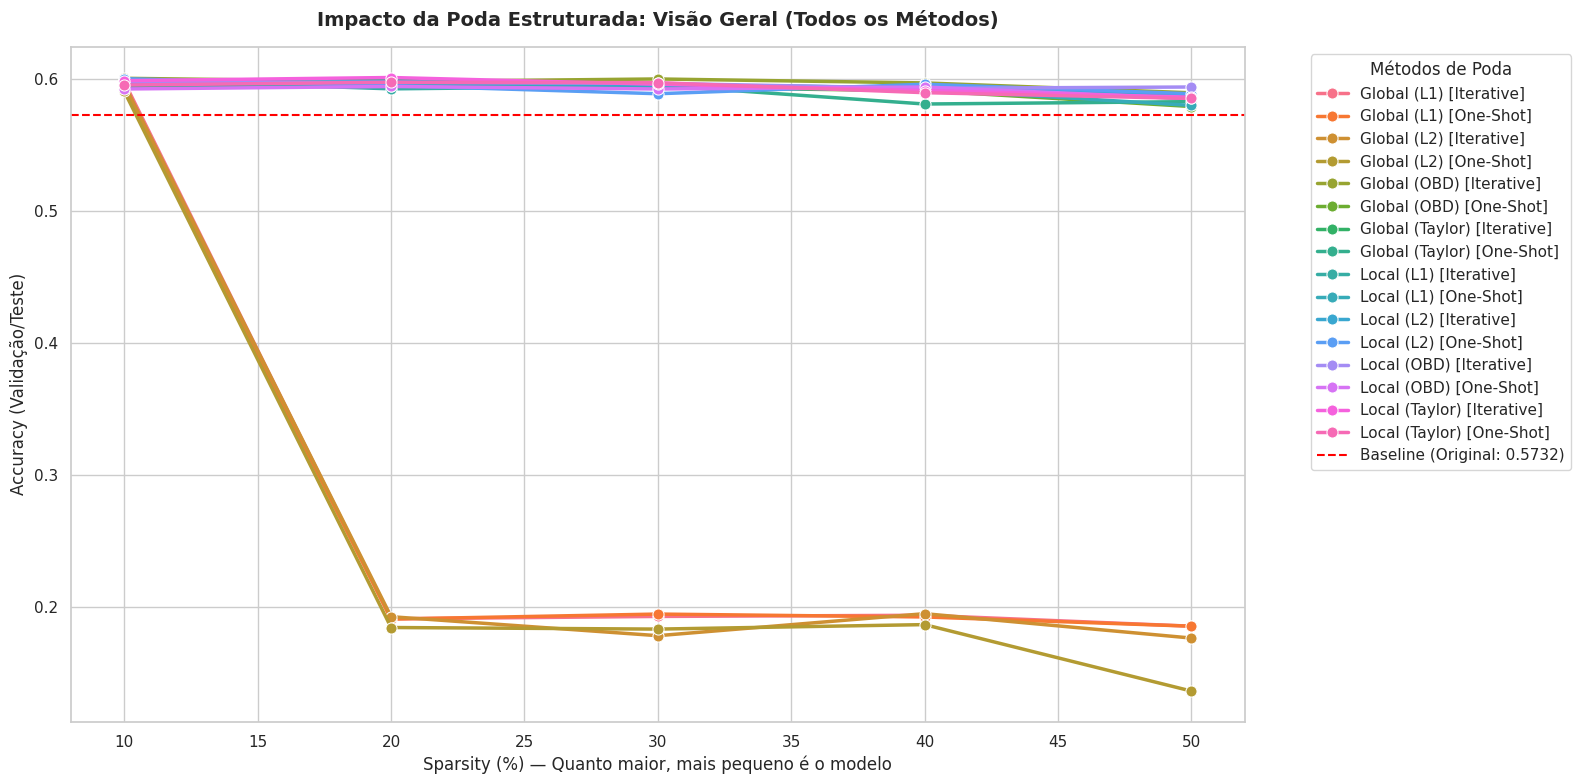


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)


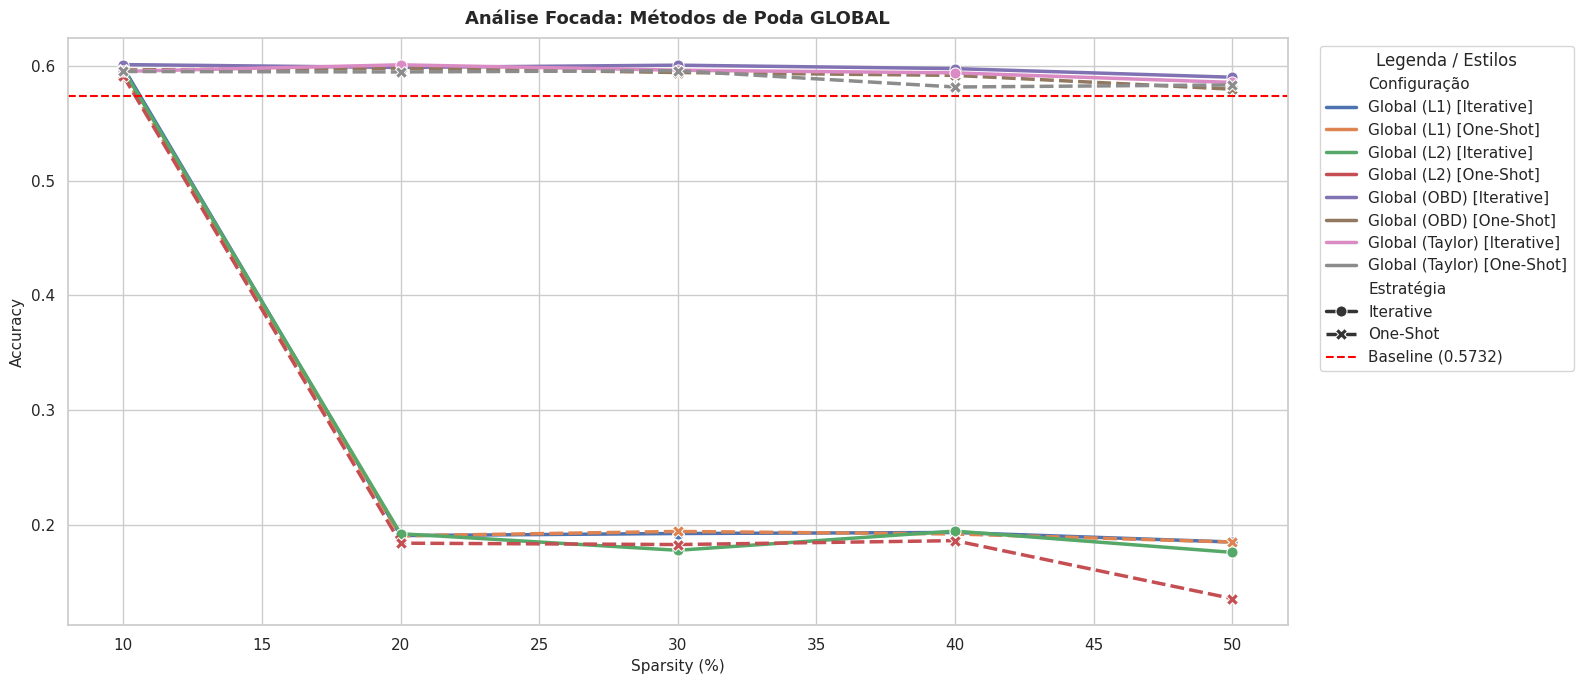

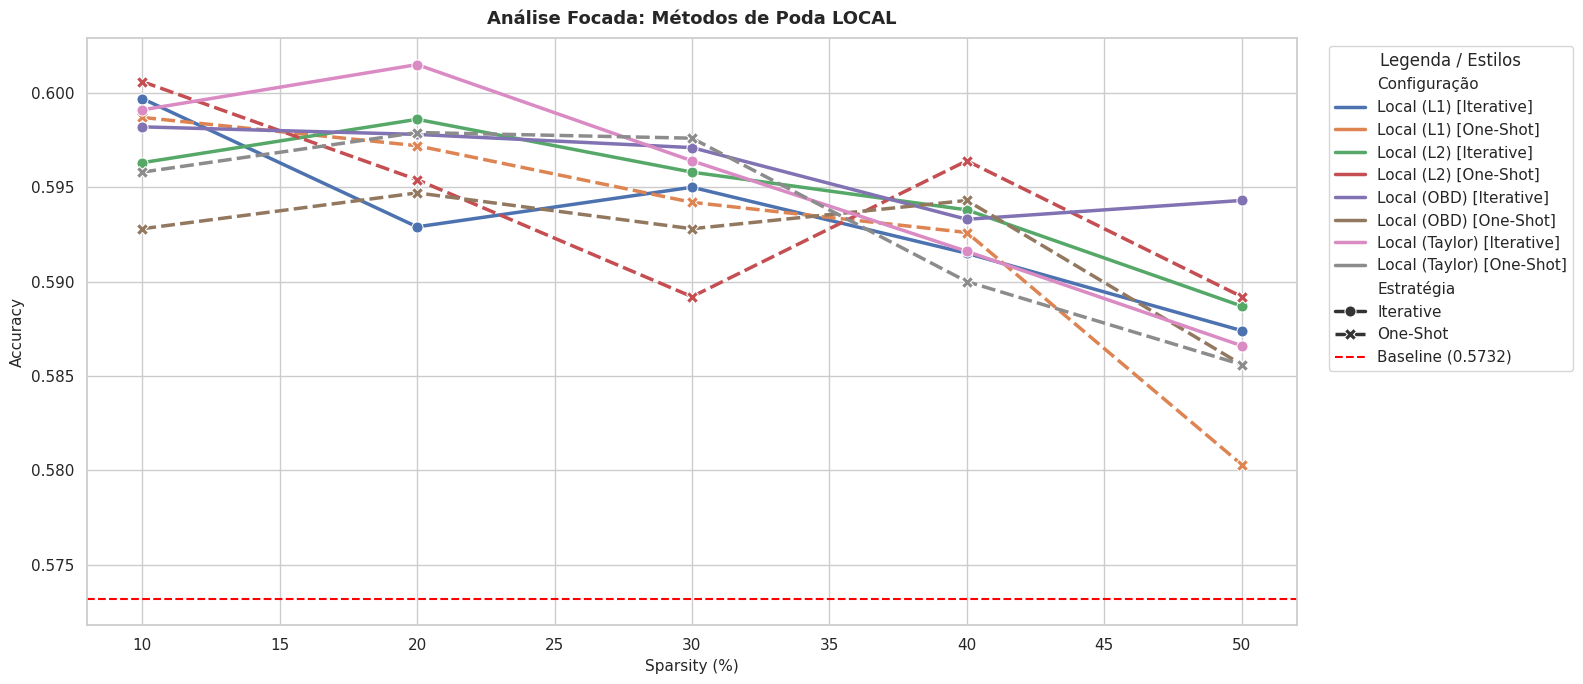

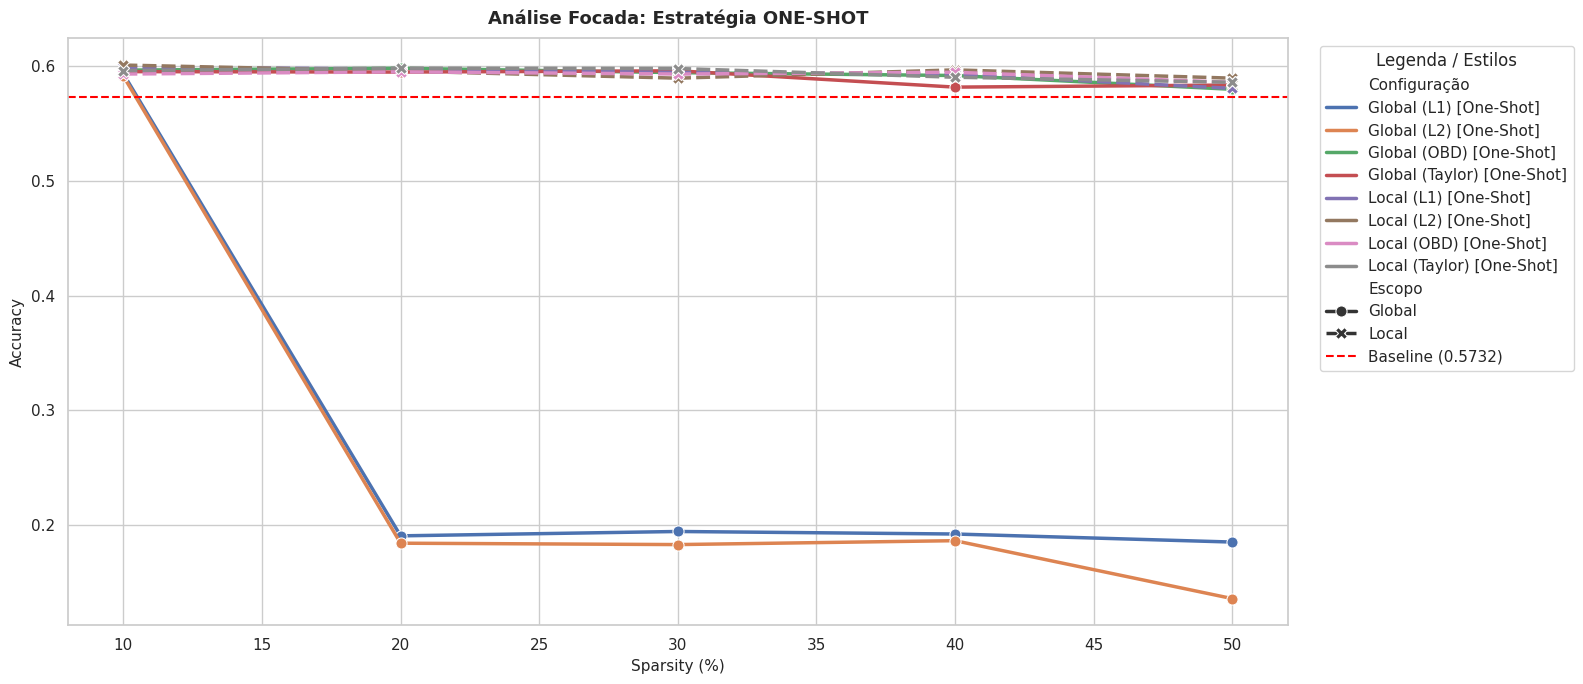

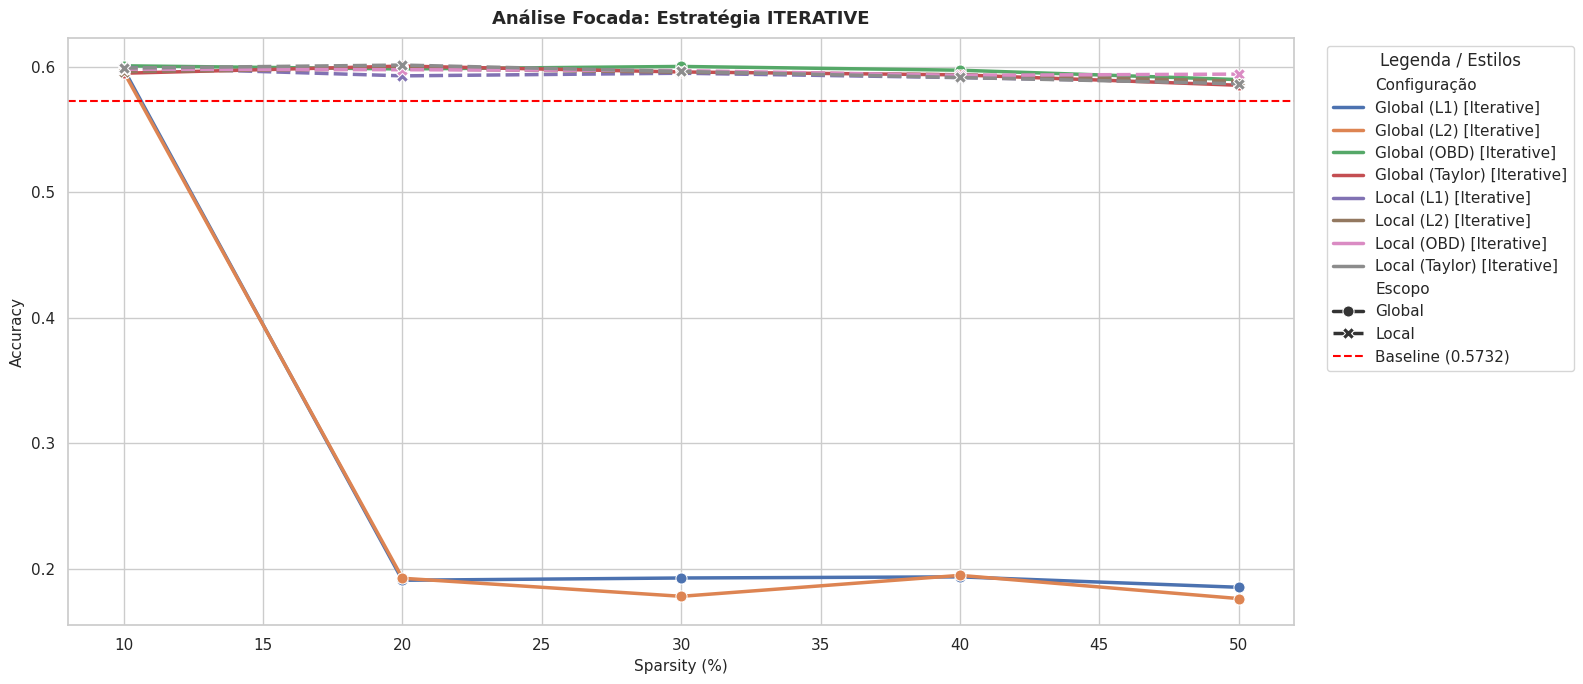

In [ ]:
# Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_mlp')
dados_grafico = []

# Guardar a precisão do baseline se existir
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name     # Ex: Global ou Local
        norma = model_path.parent.name             # Ex: L1, L2 ou Taylor
        stem = model_path.stem                     # Ex: VGG_one-shot_10pct
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "Accuracy": post.get('accuracy', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# VISÃO GERAL (TODOS OS MÉTODOS)

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="Accuracy", 
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_acc:
    plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original: {baseline_acc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Todos os Métodos)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Accuracy (Validação/Teste)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)

analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot",
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)\n{'='*80}")

for analise in analises_especificas:
    # Filtrar o dataframe para a categoria atual
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="Accuracy", 
        hue="Configuração", 
        style=analise["coluna_estilo"],  
        markers=True,                    
        linewidth=2.5,
        markersize=8
    )
    
    # Linha de referência do Baseline
    if baseline_acc:
        plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

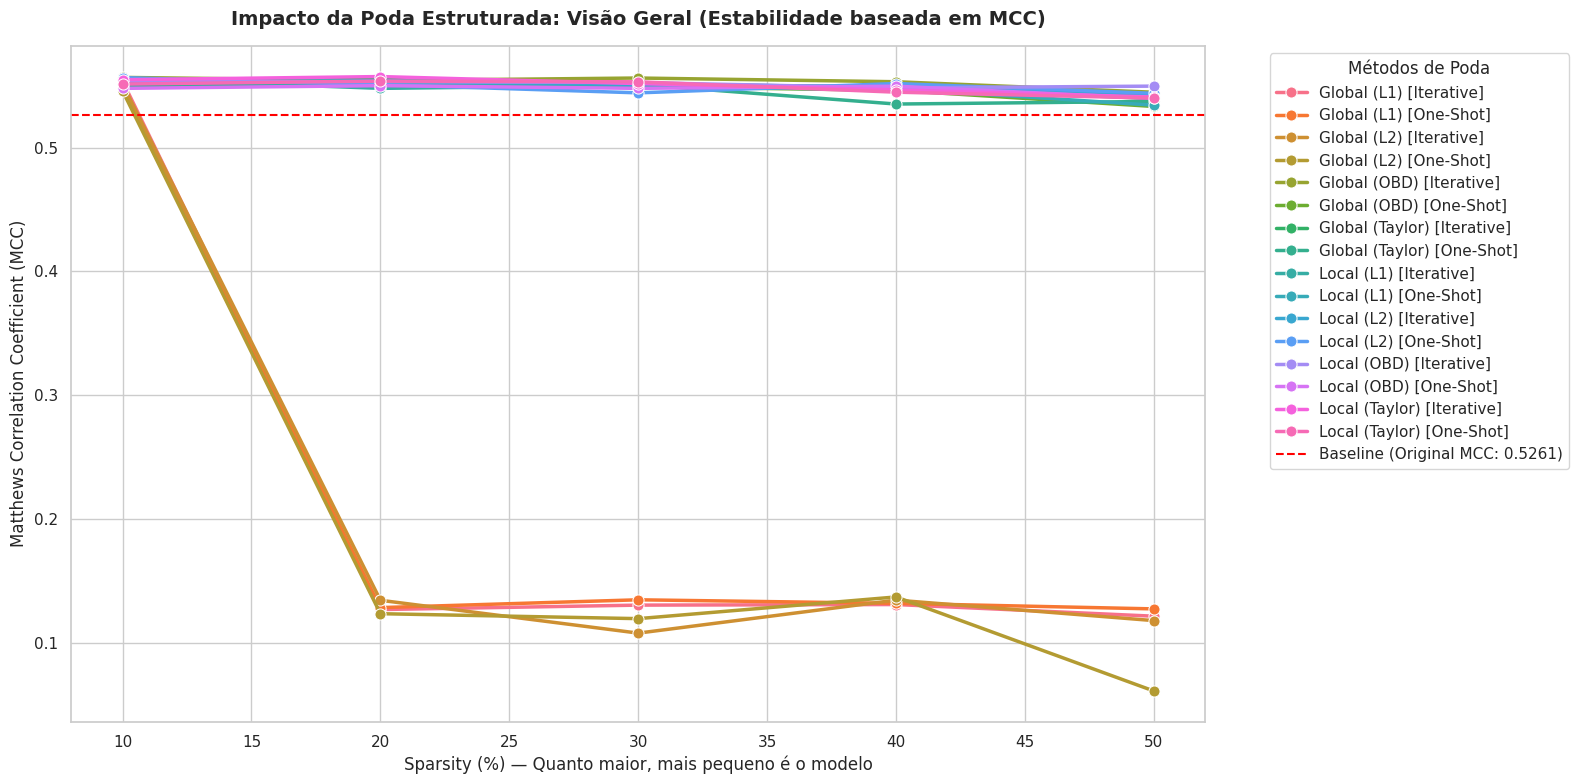


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)


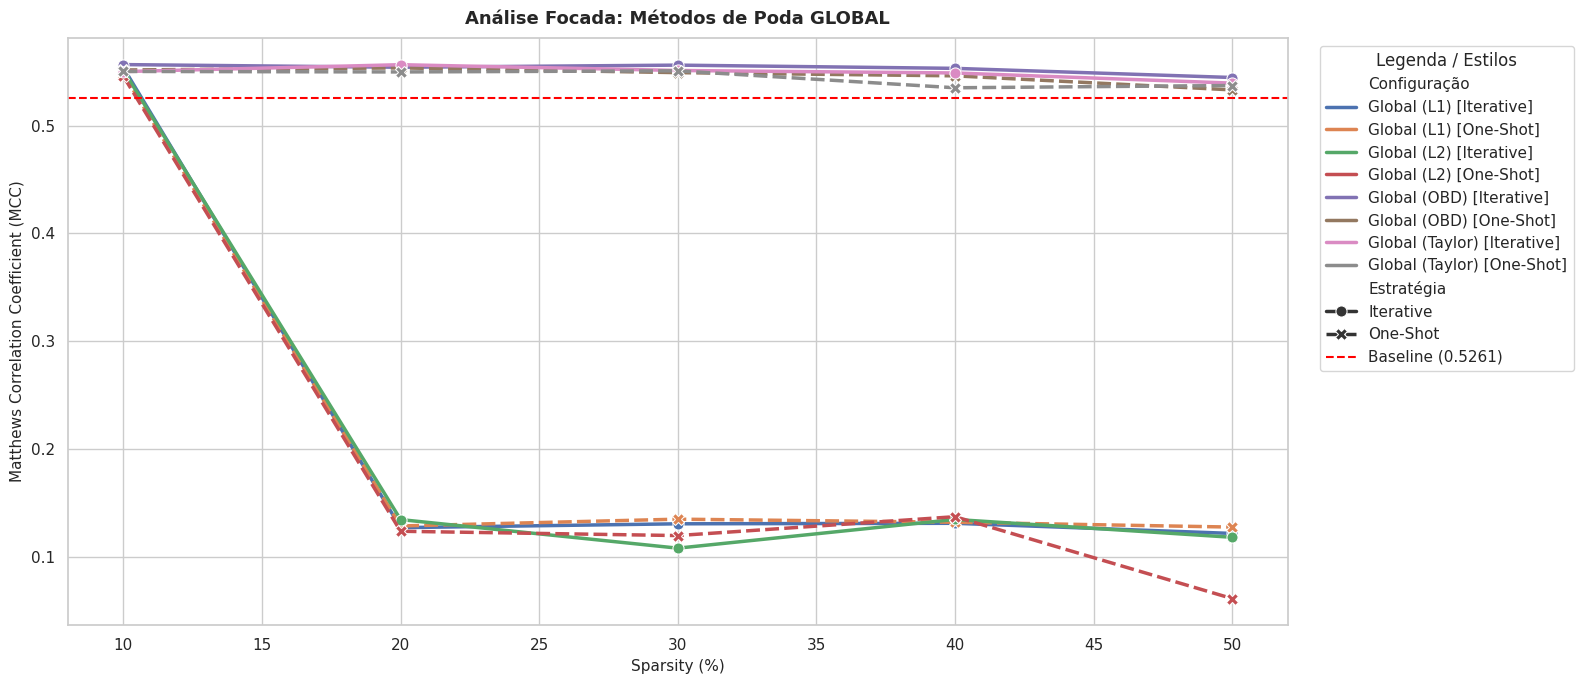

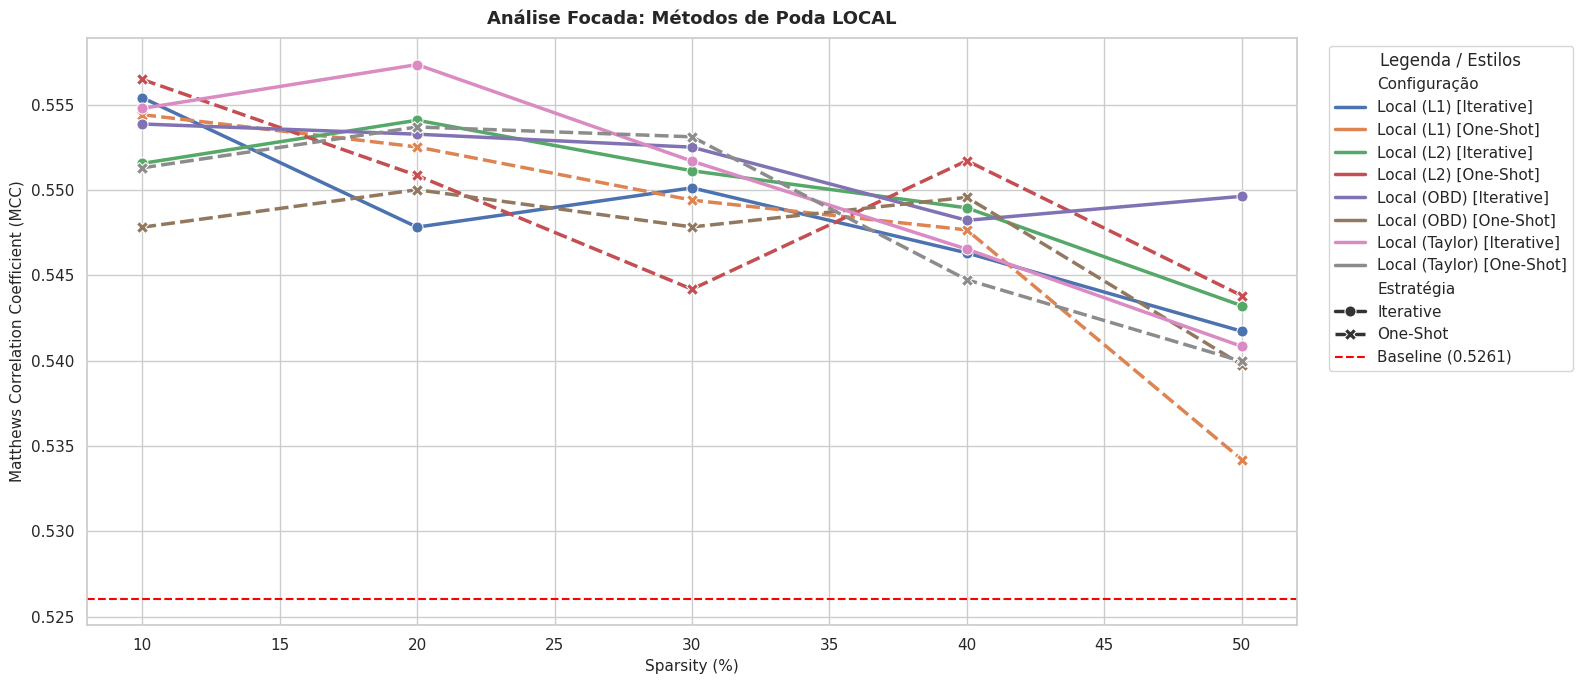

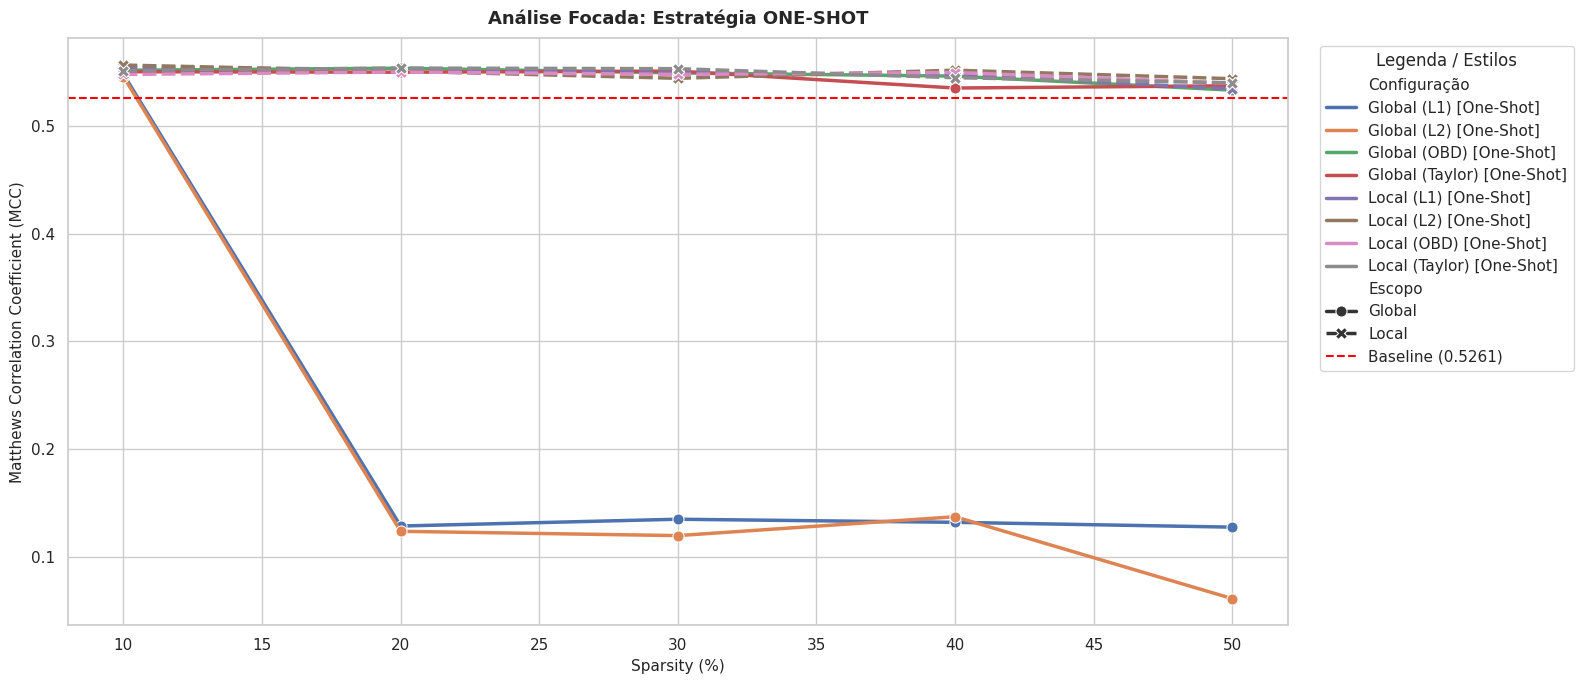

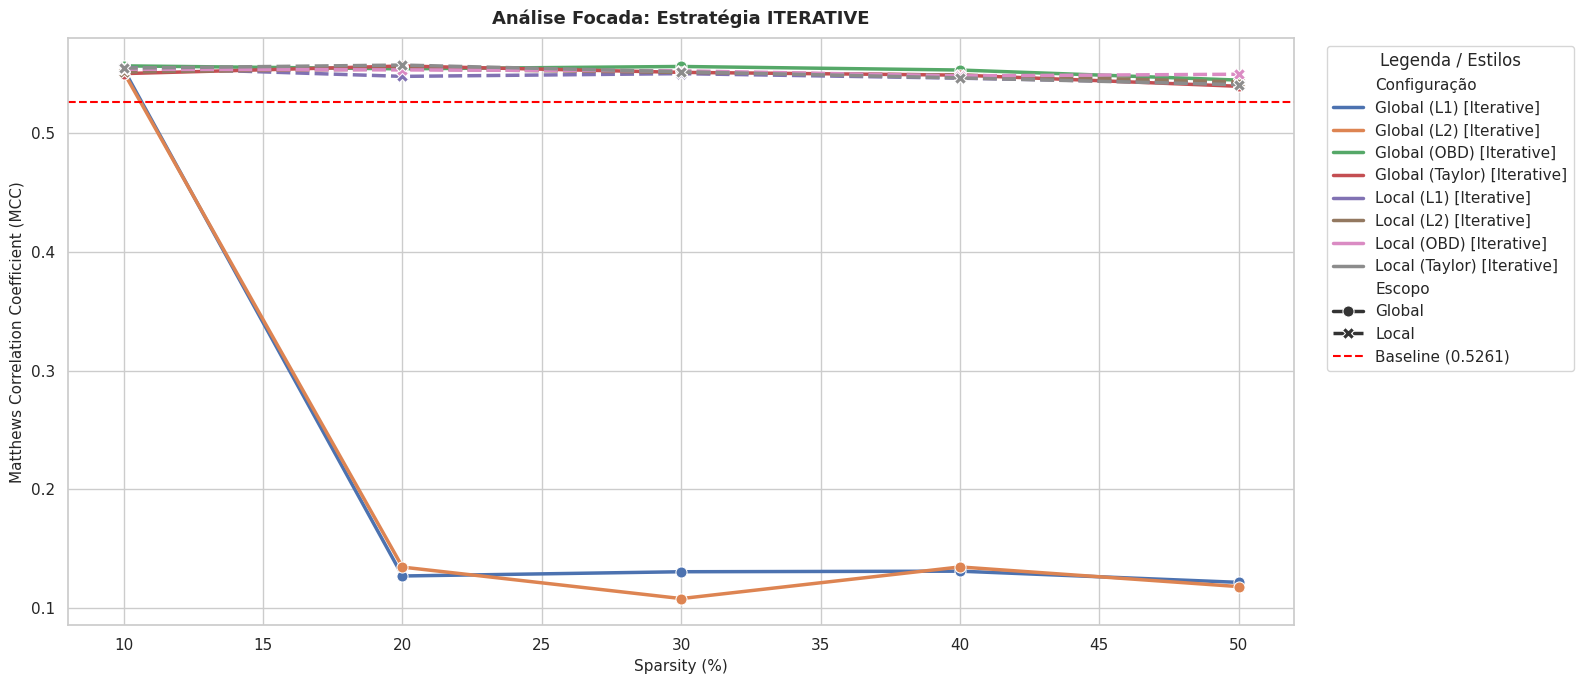

In [ ]:
# Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_mlp')
dados_grafico = []

# Guardar o MCC e a precisão do baseline se existirem
baseline_mcc = baseline_results.get('mcc', None) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

# Caso o dicionário do baseline use outra designação ou queiras extrair diretamente do df_resultados anterior:
if baseline_mcc is None and 'df_resultados' in locals():
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'MCC' in df_resultados.columns else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name
        norma = model_path.parent.name
        stem = model_path.stem
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# Ajuste automático do limite inferior do gráfico com base nos dados reais de MCC
min_mcc_detectado = df_plot['MCC'].min() if not df_plot.empty else 0.60
# Define um patamar mínimo para o gráfico não achatar as curvas (usa o menor valor ou 0.65 por segurança)
limite_inferior_y = max(0.50, min_mcc_detectado - 0.02)
limite_superior_y = (baseline_mcc + 0.02) if baseline_mcc else 0.82

# VISÃO GERAL (TODOS OS MÉTODOS)

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="MCC",
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_mcc is not None:
    plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original MCC: {baseline_mcc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Estabilidade baseada em MCC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)

analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot", 
        "coluna_estilo": "Escopo"      
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)\n{'='*80}")

for analise in analises_especificas:
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="MCC",
        hue="Configuração", 
        style=analise["coluna_estilo"],  
        markers=True,                    
        linewidth=2.5,
        markersize=8
    )
    
    if baseline_mcc is not None:
        plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_mcc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=11)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

In [ ]:
# CONFIGURAÇÃO DE TOLERÂNCIA

# Mantemos o filtro inicial pela Accuracy, mas expandimos a análise total
tolerancia_maxima_acc = 0.02

# Extração segura das métricas de referência do Baseline
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_acc = baseline_results.get('accuracy', 0)
    baseline_mcc = baseline_results.get('mcc', 0)
    baseline_kappa = baseline_results.get('cohen_kappa', 0)
else:
    baseline_acc = df_resultados[df_resultados['Método'] == 'Baseline']['Accuracy'].values[0] if 'df_resultados' in locals() else None
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'df_resultados' in locals() else 0
    baseline_kappa = df_resultados[df_resultados['Método'] == 'Baseline']['Cohen Kappa'].values[0] if 'df_resultados' in locals() else 0

if baseline_acc:
    limite_minimo_accuracy = baseline_acc - tolerancia_maxima_acc
    
    # Filtrar os modelos que passam no teste de estabilidade de Accuracy
    df_filtrado = df_resultados[df_resultados['Accuracy'] >= limite_minimo_accuracy].copy()
    
    # Remover a linha do Baseline para podermos avaliar apenas o ranking dos podados
    df_filtrado = df_filtrado[df_filtrado['Método'] != 'Baseline']
    
    # Ordenar do mais comprimido (mais leve) para o menos comprimido
    df_filtrado = df_filtrado.sort_values(by="Compressão (x)", ascending=False)
    
    print(f"=======================================================================")
    print(f"   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -{tolerancia_maxima_acc*100}%)")
    print(f"=======================================================================")
    print(f" [Métricas de Referência do Baseline Original]")
    print(f"  -> Accuracy: {baseline_acc:.4f}  |  MCC: {baseline_mcc:.4f}  |  Cohen's Kappa: {baseline_kappa:.4f}\n")
    
    if not df_filtrado.empty:
        # Colunas selecionadas a dedo para o teu relatório final (focado em compressão + robustez)
        colunas_relatorio = [
            "Método", "Sparsity (%)", "Compressão (x)", 
            "Accuracy", "MCC", "Cohen Kappa", 
            "Latência (s)", "VRAM (MB)"
        ]
        
        # Selecionar os top 5 modelos mais leves que não quebraram a performance
        df_top = df_filtrado[colunas_relatorio].head(10)
        
        # Aplicar um estilo visual para realçar os campeões de robustez
        estilo_executivo = df_top.style.set_properties(**{'text-align': 'center'}) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
            .highlight_max(subset=['MCC', 'Cohen Kappa', 'Compressão (x)'], color='lightgreen') \
            .highlight_min(subset=['Latência (s)'], color='lightcyan') \
            .format({
                "Accuracy": "{:.4f}",
                "MCC": "{:.4f}",
                "Cohen Kappa": "{:.4f}",
                "Latência (s)": "{:.4f}",
                "Compressão (x)": "{:.2f}x"
            })
        
        display(estilo_executivo)
        
        # Pequeno aviso analítico no terminal para te ajudar a decidir
        melhor_mcc_idx = df_top['MCC'].idxmax()
        print(f"Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o \n"
              f"'{df_top.loc[melhor_mcc_idx, 'Método']}' com MCC de {df_top.loc[melhor_mcc_idx, 'MCC']:.4f} "
              f"e uma compressão de {df_top.loc[melhor_mcc_idx, 'Compressão (x)']:.2f}x.")
        
    else:
        print("Nenhum modelo podado conseguiu ficar dentro da tolerância exigida.")
else:
    print("Erro: Não foi possível determinar o 'baseline_acc' para aplicar o filtro.")

   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -2.0%)
 [Métricas de Referência do Baseline Original]
  -> Accuracy: 0.5732  |  MCC: 0.5261  |  Cohen's Kappa: 0.5258



,Método,Sparsity (%),Compressão (x),Accuracy,MCC,Cohen Kappa,Latência (s),VRAM (MB)
30,Global OBD (Magnitude) (one-shot),50,3.12x,0.5795,0.5332,0.5328,1.3455,172.740000
25,Global OBD (Magnitude) (iterative),50,3.02x,0.5899,0.5447,0.5443,1.0974,142.580000
29,Global OBD (Magnitude) (one-shot),40,2.41x,0.5915,0.5462,0.5461,1.2415,189.220000
45,Local L1 (Magnitude) (iterative),50,2.35x,0.5874,0.5417,0.5416,1.2902,135.530000
65,Local OBD (Magnitude) (iterative),50,2.35x,0.5943,0.5496,0.5492,1.2527,159.650000
75,Local Taylor (Gradiente) (iterative),50,2.35x,0.5866,0.5408,0.5407,1.1330,277.960000
55,Local L2 (Magnitude) (iterative),50,2.35x,0.5887,0.5432,0.5430,1.1695,134.150000
50,Local L1 (Magnitude) (one-shot),50,2.34x,0.5803,0.5342,0.5337,1.0636,134.600000
80,Local Taylor (Gradiente) (one-shot),50,2.34x,0.5856,0.5400,0.5396,1.2034,305.010000
60,Local L2 (Magnitude) (one-shot),50,2.34x,0.5892,0.5438,0.5436,1.1134,134.660000


Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o 
'Local OBD (Magnitude) (iterative)' com MCC de 0.5496 e uma compressão de 2.35x.


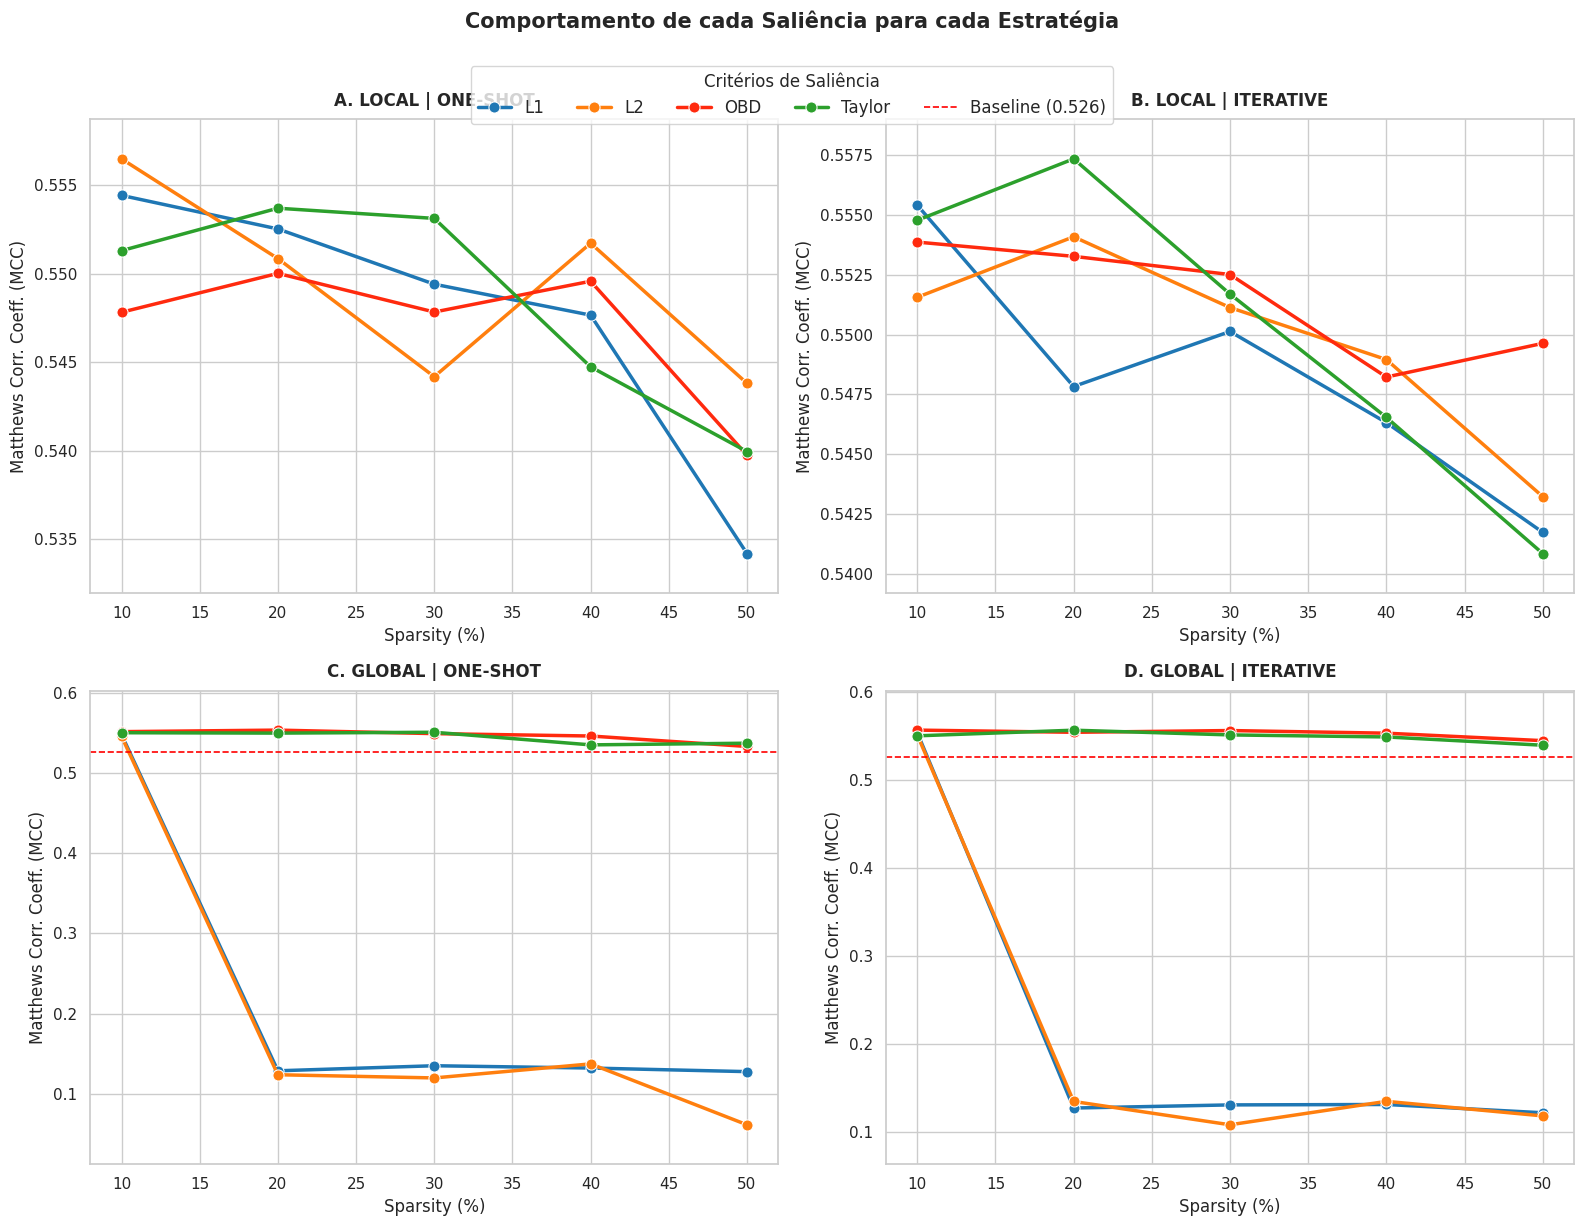

In [ ]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from pathlib import Path

# Ativa a interatividade

# Recolha detalhada dos dados (incluindo explicitamente a Saliência)
save_dir = Path('modelos_podados_mlp')
dados_analise = []

# Extrair referências do Baseline
baseline_mcc = baseline_results.get('mcc', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        ambito = model_path.parent.parent.name     # Global / Local
        norma = model_path.parent.name             # L1 / L2 / Taylor / OBD
        stem = model_path.stem                     # VGG_one-shot_10pct
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # one-shot / iterative
            sparsity_pct = int(match.group(2))
            
            dados_analise.append({
                "Ambito": ambito,
                "Saliência": norma,                 # L1, L2, Taylor, OBD
                "Estratégia": estrategia.lower(),   # one-shot ou iterative
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Accuracy": post.get('accuracy', 0)
            })
    except Exception:
        continue

df_saliencia = pd.DataFrame(dados_analise)

# CONSTRUÇÃO DA MATRIZ DE GRÁFICOS 2x2

# sharey=False para permitir zooms independentes em cada quadrante
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False, sharey=False)
sns.set_theme(style="whitegrid")

# Definição dos quadrantes: (Linha, Coluna) -> (Ambito, Estratégia)
quadrantes = [
    {"ambito": "Local",  "estrategia": "one-shot",  "ax": axes[0, 0], "titulo": "A. LOCAL | ONE-SHOT"},
    {"ambito": "Local",  "estrategia": "iterative", "ax": axes[0, 1], "titulo": "B. LOCAL | ITERATIVE"},
    {"ambito": "Global", "estrategia": "one-shot",  "ax": axes[1, 0], "titulo": "C. GLOBAL | ONE-SHOT"},
    {"ambito": "Global", "estrategia": "iterative", "ax": axes[1, 1], "titulo": "D. GLOBAL | ITERATIVE"}
]

# Palete de cores fixa 
cores_saliencia = {"L1": "#1f77b4", "L2": "#ff7f0e", "Taylor": "#2ca02c", "OBD": "#ff2a0e"}

for q in quadrantes:
    ax = q["ax"]
    # Filtrar dados para este cenário específico
    df_sub = df_saliencia[
        (df_saliencia["Ambito"].str.lower() == q["ambito"].lower()) & 
        (df_saliencia["Estratégia"] == q["estrategia"])
    ]

    if not df_sub.empty:
        # Calcular limites dinâmicos para cada quadrante isolado
        mcc_min = df_sub["MCC"].min()
        mcc_max = df_sub["MCC"].max()
        margem = (mcc_max - mcc_min) * 0.10 if mcc_max != mcc_min else 0.1
        
        # Desenhar as curvas de saliência
        sns.lineplot(
            data=df_sub, x="Sparsity (%)", y="MCC", hue="Saliência",
            palette=cores_saliencia, marker="o", linewidth=2.5, markersize=8, ax=ax
        )
        ax.set_ylim(mcc_min - margem, mcc_max + margem)
    else:
        ax.text(0.5, 0.5, "Sem dados para esta combinação", ha='center', va='center', fontsize=12, color='gray')

    # Linha horizontal do Baseline
    if baseline_mcc is not None:
        ax.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_mcc:.3f})')
    
    ax.set_title(q["titulo"], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Matthews Corr. Coeff. (MCC)")
    
    # Previne erros se o quadrante estiver vazio
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Criar uma legenda única e elegante para o topo do gráfico
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=5, fontsize=12, title="Critérios de Saliência")
plt.suptitle("Comportamento de cada Saliência para cada Estratégia", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

### Análise Multiobjetivo com Fronteiras de Pareto

A optimização de modelos comprimidos envolve objectivos frequentemente contraditórios:

- Maximizar accuracy
- Minimizar latência
- Reduzir número de parâmetros

Para identificar as melhores soluções de compromisso é utilizada uma **análise de Pareto**, que permite destacar configurações não dominadas.

Uma solução é considerada **Pareto-ótima** quando não é possível melhorar uma métrica sem degradar outra.

In [ ]:
def compute_pareto_front(df, maximize_metrics=None, minimize_metrics=None,):
    """
    Calcula soluções Pareto-ótimas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com resultados.

    maximize_metrics : list[str]
        Métricas a maximizar.

    minimize_metrics : list[str]
        Métricas a minimizar.

    Returns
    -------
    pd.DataFrame
        Apenas soluções Pareto-ótimas.
    """
    maximize_metrics = maximize_metrics or []
    minimize_metrics = minimize_metrics or []
    metric_cols = maximize_metrics + minimize_metrics

    temp = df[metric_cols].copy()

    # converter maximização -> minimização
    for col in maximize_metrics:
        temp[col] = -temp[col]

    values = temp.to_numpy()
    is_pareto = np.ones(len(values), dtype=bool)

    for i, candidate in enumerate(values):
        if not is_pareto[i]:
            continue

        dominated = np.all(candidate <= values, axis=1) & \
                    np.any(candidate < values, axis=1)
        dominated[i] = False
        is_pareto[dominated] = False

    return df[is_pareto].copy()


def plot_pareto_front(df, x_metric="Parâmetros", y_metric="Accuracy", color_metric="MCC", maximize_metrics=None, 
                      minimize_metrics=None, label_column="Método", title="Pareto Front"):
    """
    Plot da Pareto Front.
    """
    if maximize_metrics is None:
        maximize_metrics = [y_metric, color_metric]

    if minimize_metrics is None:
        minimize_metrics = [x_metric]

    pareto_df = compute_pareto_front(
        df=df,
        maximize_metrics=maximize_metrics,
        minimize_metrics=minimize_metrics
    )

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        df[x_metric],
        df[y_metric],
        c=df[color_metric],
        s=120,
        alpha=0.7
    )
    plt.scatter(
        pareto_df[x_metric],
        pareto_df[y_metric],
        s=280,
        marker="*"
    )

    for _, row in pareto_df.iterrows():

        label = (f"{row[label_column]}"f"\n({int(row['Sparsity (%)']*100)}%)")
        plt.annotate(label,(row[x_metric], row[y_metric]),fontsize=8)

    plt.xlabel(x_metric)
    plt.ylabel(y_metric)
    plt.title(title)

    plt.colorbar(scatter,label=color_metric)

    plt.grid(True)
    plt.show()

    return pareto_df

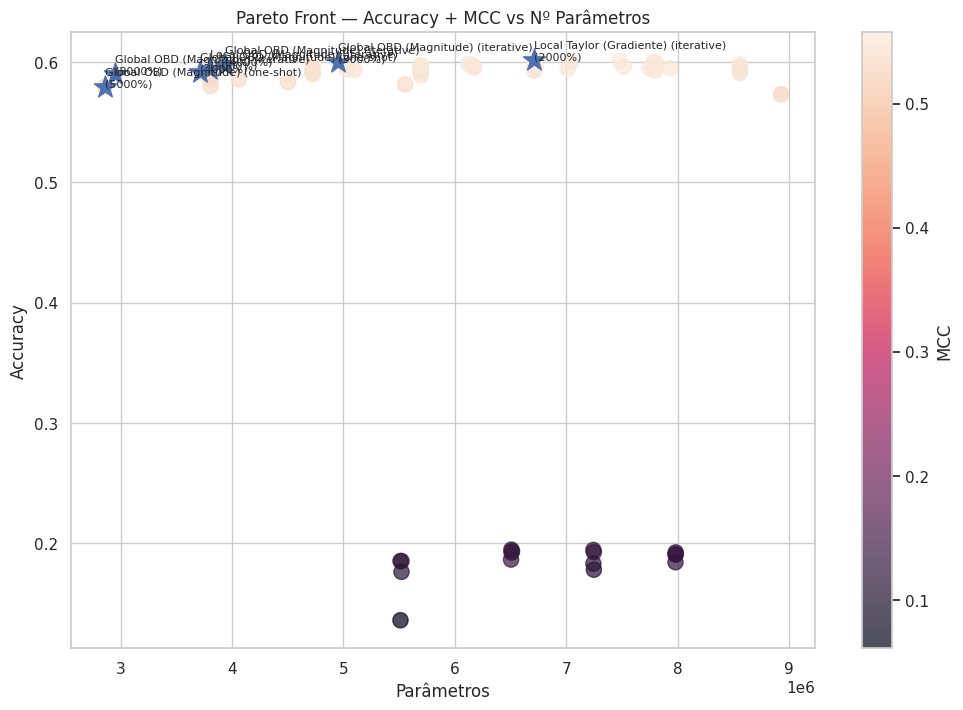

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
23,Global OBD (Magnitude) (iterative),30,4950021,1.80,0.6004,1.2614,0.6004,0.6001,0.6001,0.6004,0.6004,0.5995,0.5995,0.5560,0.5562,1.1408,185.94
24,Global OBD (Magnitude) (iterative),40,3941270,2.27,0.5974,1.2494,0.5974,0.5987,0.5987,0.5974,0.5974,0.5956,0.5956,0.5527,0.5532,1.2222,166.65
25,Global OBD (Magnitude) (iterative),50,2954533,3.02,0.5899,1.2211,0.5899,0.5928,0.5928,0.5899,0.5899,0.5898,0.5898,0.5443,0.5447,1.0974,142.58
29,Global OBD (Magnitude) (one-shot),40,3711399,2.41,0.5915,1.2318,0.5915,0.5889,0.5889,0.5915,0.5915,0.5896,0.5896,0.5461,0.5462,1.2415,189.22
30,Global OBD (Magnitude) (one-shot),50,2858875,3.12,0.5795,1.2241,0.5795,0.5806,0.5806,0.5795,0.5795,0.5782,0.5782,0.5328,0.5332,1.3455,172.74
65,Local OBD (Magnitude) (iterative),50,3803641,2.35,0.5943,1.2225,0.5943,0.5961,0.5961,0.5943,0.5943,0.5932,0.5932,0.5492,0.5496,1.2527,159.65
72,Local Taylor (Gradiente) (iterative),20,6712305,1.33,0.6015,1.2729,0.6015,0.5988,0.5988,0.6015,0.6015,0.5995,0.5995,0.5572,0.5574,1.2905,343.44


In [52]:
pareto_acc_mcc = plot_pareto_front(
    df=df_resultados,
    x_metric="Parâmetros",
    y_metric="Accuracy",
    color_metric="MCC",
    maximize_metrics=["Accuracy", "MCC"],
    minimize_metrics=["Parâmetros"],
    label_column="Método",
    title="Pareto Front — Accuracy + MCC vs Nº Parâmetros"
)

pareto_acc_mcc

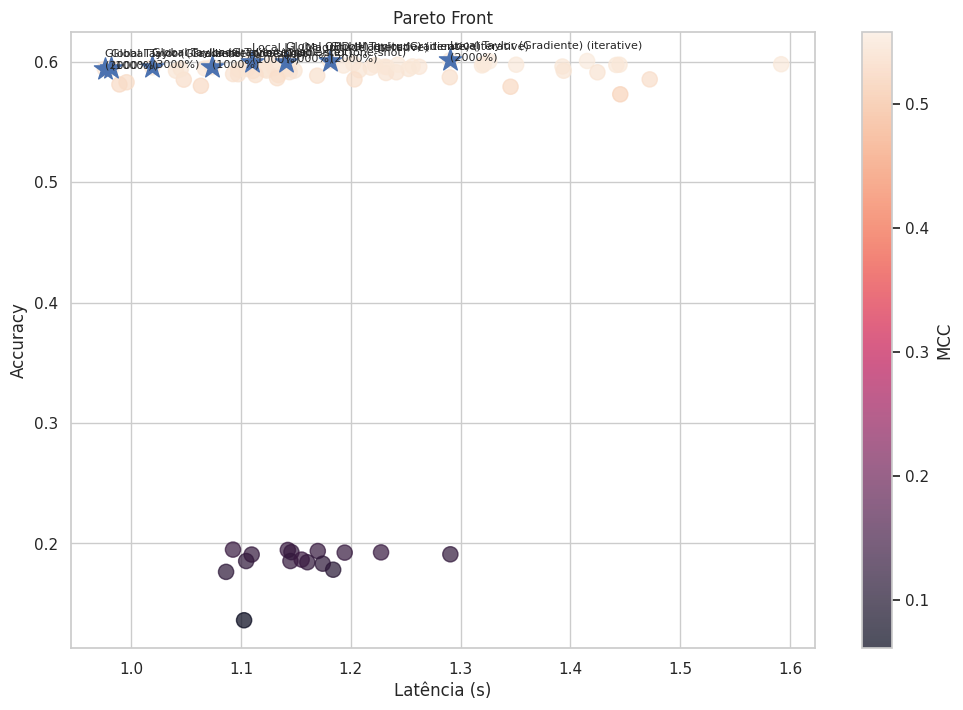

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
23,Global OBD (Magnitude) (iterative),30,4950021,1.80,0.6004,1.2614,0.6004,0.6001,0.6001,0.6004,0.6004,0.5995,0.5995,0.5560,0.5562,1.1408,185.94
32,Global Taylor (Gradiente) (iterative),20,7045869,1.27,0.6007,1.2589,0.6007,0.5983,0.5983,0.6007,0.6007,0.5984,0.5984,0.5563,0.5566,1.1812,708.43
36,Global Taylor (Gradiente) (one-shot),10,7745533,1.15,0.5949,1.2803,0.5949,0.5963,0.5963,0.5949,0.5949,0.5936,0.5936,0.5499,0.5503,0.9819,704.99
37,Global Taylor (Gradiente) (one-shot),20,7013483,1.27,0.5945,1.2459,0.5945,0.5969,0.5969,0.5945,0.5945,0.5938,0.5938,0.5494,0.5498,0.9761,715.78
38,Global Taylor (Gradiente) (one-shot),30,6168483,1.45,0.5956,1.2193,0.5956,0.5975,0.5975,0.5956,0.5956,0.5957,0.5957,0.5507,0.5509,1.0193,703.16
41,Local L1 (Magnitude) (iterative),10,7783509,1.15,0.5997,1.2976,0.5997,0.6012,0.6012,0.5997,0.5997,0.5995,0.5995,0.5552,0.5554,1.1101,159.99
72,Local Taylor (Gradiente) (iterative),20,6712305,1.33,0.6015,1.2729,0.6015,0.5988,0.5988,0.6015,0.6015,0.5995,0.5995,0.5572,0.5574,1.2905,343.44
76,Local Taylor (Gradiente) (one-shot),10,7797041,1.15,0.5958,1.2707,0.5958,0.5952,0.5952,0.5958,0.5958,0.5936,0.5936,0.5509,0.5513,1.0738,329.55


In [53]:
pareto_lat_acc = plot_pareto_front(
    df_resultados,

    x_metric="Latência (s)",
    y_metric="Accuracy",
    color_metric="MCC",

    maximize_metrics=[
        "Accuracy",
        "MCC"
    ],

    minimize_metrics=[
        "Latência (s)"
    ]
)
pareto_lat_acc

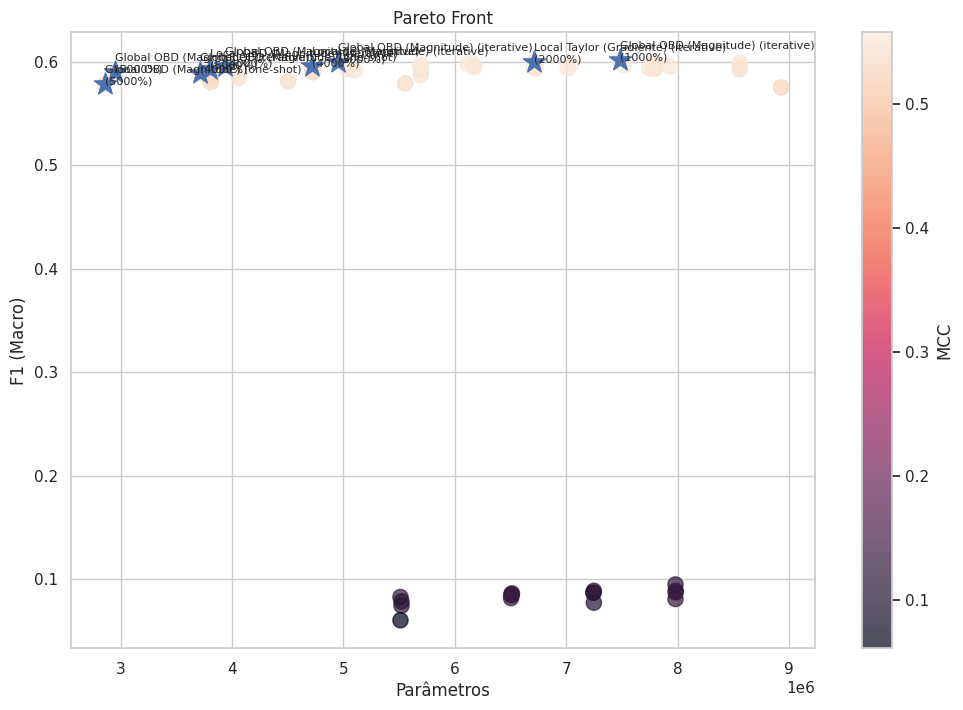

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
21,Global OBD (Magnitude) (iterative),10,7477937,1.19,0.6009,1.3096,0.6009,0.6032,0.6032,0.6009,0.6009,0.6015,0.6015,0.5566,0.5567,1.4152,195.40
23,Global OBD (Magnitude) (iterative),30,4950021,1.80,0.6004,1.2614,0.6004,0.6001,0.6001,0.6004,0.6004,0.5995,0.5995,0.5560,0.5562,1.1408,185.94
24,Global OBD (Magnitude) (iterative),40,3941270,2.27,0.5974,1.2494,0.5974,0.5987,0.5987,0.5974,0.5974,0.5956,0.5956,0.5527,0.5532,1.2222,166.65
25,Global OBD (Magnitude) (iterative),50,2954533,3.02,0.5899,1.2211,0.5899,0.5928,0.5928,0.5899,0.5899,0.5898,0.5898,0.5443,0.5447,1.0974,142.58
29,Global OBD (Magnitude) (one-shot),40,3711399,2.41,0.5915,1.2318,0.5915,0.5889,0.5889,0.5915,0.5915,0.5896,0.5896,0.5461,0.5462,1.2415,189.22
30,Global OBD (Magnitude) (one-shot),50,2858875,3.12,0.5795,1.2241,0.5795,0.5806,0.5806,0.5795,0.5795,0.5782,0.5782,0.5328,0.5332,1.3455,172.74
54,Local L2 (Magnitude) (iterative),40,4722269,1.89,0.5938,1.2484,0.5938,0.6004,0.6004,0.5938,0.5938,0.5958,0.5958,0.5487,0.5490,1.1219,149.58
65,Local OBD (Magnitude) (iterative),50,3803641,2.35,0.5943,1.2225,0.5943,0.5961,0.5961,0.5943,0.5943,0.5932,0.5932,0.5492,0.5496,1.2527,159.65
72,Local Taylor (Gradiente) (iterative),20,6712305,1.33,0.6015,1.2729,0.6015,0.5988,0.5988,0.6015,0.6015,0.5995,0.5995,0.5572,0.5574,1.2905,343.44


In [54]:
pareto_param_f1 = plot_pareto_front(
    df_resultados,

    x_metric="Parâmetros",
    y_metric="F1 (Macro)",
    color_metric="MCC",

    maximize_metrics=[
        "F1 (Macro)",
        "MCC"
    ],

    minimize_metrics=[
        "Parâmetros"
    ]
)
pareto_param_f1

   RANKING COMPLETO DOS INDIVÍDUOS NAS FRENTES DE PARETO (PRESERVANDO ÍNDICES E VALORES ORIGINAIS)
 Índice Original                                Método  Sparsity (%) Escopo (Global/Local) Saliência Estratégia de Poda  Frequência (Nº de Frentes)  Parâmetros  Compressão (x)  Accuracy   Loss  Bal. Acc  Prec (Macro)  Prec (Weighted)  Rec (Macro)  Rec (Weighted)  F1 (Macro)  F1 (Weighted)  Cohen Kappa    MCC  Latência (s)  VRAM (MB)
              23    Global OBD (Magnitude) (iterative)            30                Global       OBD          iterative                           3     4950021            1.80    0.6004 1.2614    0.6004        0.6001           0.6001       0.6004          0.6004      0.5995         0.5995       0.5560 0.5562        1.1408     185.94
              72  Local Taylor (Gradiente) (iterative)            20                 Local    Taylor          iterative                           3     6712305            1.33    0.6015 1.2729    0.6015        0.5988           0.59

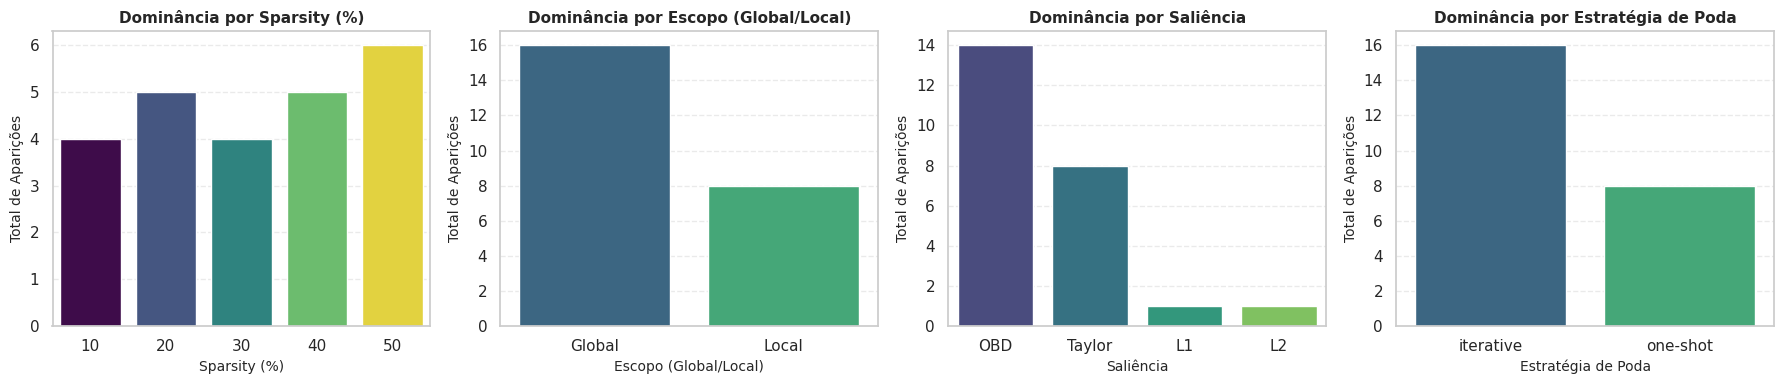

In [ ]:
frentes_pareto = {
    "Acc vs MCC": pareto_acc_mcc if 'pareto_acc_mcc' in locals() else None,
    "Lat vs Acc": pareto_lat_acc if 'pareto_lat_acc' in locals() else None,
    "Param vs F1": pareto_param_f1 if 'pareto_param_f1' in locals() else None
}

df_acumulado = []

for nome_frente, df in frentes_pareto.items():
    if df is not None:
        df_temp = df.copy()
        # Reter o índice numérico original que aponta diretamente para o teu df_resultados
        df_temp['Índice Original'] = df_temp.index
        df_temp['Frente de Pareto'] = nome_frente
        
        # Extrair e isolar os hiperparâmetros codificados na coluna 'Método'
        escopos = []
        saliencias = []
        estrategias = []
        
        for meto in df_temp['Método']:
            if str(meto).strip() == 'Baseline':
                escopos.append('Baseline')
                saliencias.append('Baseline')
                estrategias.append('Baseline')
            else:
                parts = str(meto).split()
                # Primeiro termo é o Escopo (Global / Local)
                escopo = parts[0] if len(parts) > 0 else "Desconhecido"
                # Segundo termo é a Saliência/Norma (L1 / L2 / Taylor)
                saliencia = parts[1] if len(parts) > 1 else "Desconhecido"
                
                # Capturar a estratégia dentro dos últimos parênteses (one-shot / iterative)
                match_est = re.search(r'\(([^)]+)\)$', str(meto))
                estrategia = match_est.group(1) if match_est else "Desconhecido"
                
                escopos.append(escopo)
                saliencias.append(saliencia)
                estrategias.append(estrategia)
                
        df_temp['Escopo (Global/Local)'] = escopos
        df_temp['Saliência'] = saliencias
        df_temp['Estratégia de Poda'] = estrategias
        
        df_acumulado.append(df_temp)

if df_acumulado:
    # Juntar todas as frentes de Pareto detetadas numa única estrutura intermédia
    df_total_pareto = pd.concat(df_acumulado, ignore_index=True)
    
    # Definir as colunas estruturadas para o identificador único do indivíduo
    colunas_chave = ['Método', 'Sparsity (%)', 'Escopo (Global/Local)', 'Saliência', 'Estratégia de Poda']
    
    # Contar a frequência com que cada indivíduo (combinação única) surge nas frentes
    df_frequencia = df_total_pareto.groupby(colunas_chave).size().reset_index(name='Frequência (Nº de Frentes)')
    
    # Resgatar todas as métricas originais removendo duplicados de frentes cruzadas
    df_individuos_unicos = df_total_pareto.drop_duplicates(subset=['Método', 'Sparsity (%)']).copy()
    df_ranking_completo = pd.merge(df_individuos_unicos, df_frequencia, on=colunas_chave).sort_values(by='Frequência (Nº de Frentes)', ascending=False)
    
    # Reordenar as colunas colocando os IDs e Frequências no início para facilitar a leitura
    colunas_excluir = colunas_chave + ['Frente de Pareto', 'Frequência (Nº de Frentes)', 'Índice Original']
    colunas_metricas = [col for col in df_ranking_completo.columns if col not in colunas_excluir]
    ordem_colunas = ['Índice Original'] + colunas_chave + ['Frequência (Nº de Frentes)'] + colunas_metricas
    
    print("="*120)
    print("   RANKING COMPLETO DOS INDIVÍDUOS NAS FRENTES DE PARETO (PRESERVANDO ÍNDICES E VALORES ORIGINAIS)")
    print("="*120)
    print(df_ranking_completo[ordem_colunas].to_string(index=False))
    print("="*120)
    
    # Análise Estatística Isolada por Atributo (Sparsity, Escopo, Saliência, etc.)
    print("\n" + "="*70)
    print("   CONTAGEM ISOLADA POR PARÂMETRO DE ENGENHARIA NAS FRENTES OTIMIZADAS")
    print("="*70)
    
    atributos_analise = ['Sparsity (%)', 'Escopo (Global/Local)', 'Saliência', 'Estratégia de Poda']
    
    # Configurar múltiplos gráficos de barras lado a lado
    fig, axes = plt.subplots(1, len(atributos_analise), figsize=(4.5 * len(atributos_analise), 4))
    
    for i, col in enumerate(atributos_analise):
        # Contar ocorrências totais agregadas nas frentes
        contagem_atributo = df_total_pareto[col].value_counts().reset_index()
        contagem_atributo.columns = [col, 'Aparições nas Frentes']
        
        print(f"\n▶ Distribuição para a variável '{col}':")
        print(contagem_atributo.to_string(index=False))
        
        # Desenhar o respetivo gráfico estatístico
        sns.barplot(
            data=contagem_atributo, 
            x=col, 
            y='Aparições nas Frentes', 
            ax=axes[i], 
            palette='viridis', 
            hue=col, 
            legend=False
        )
        axes[i].set_title(f'Dominância por {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Total de Aparições', fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.show()

else:
    print("Erro: Nenhuma das tabelas de Pareto foi encontrada. Executa as células anteriores do notebook primeiro.")